In [1]:
import sys
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()
print(current_dir)

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import time

import matplotlib.pyplot as plt
import h5py
import numpy as np
from ripser import Rips, ripser
from sklearn import preprocessing
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.stats import binned_statistic_2d, pearsonr
from scipy.sparse import coo_matrix
from scipy.linalg import eigh
from scipy.sparse.linalg import lsmr
from scipy import stats
from datetime import datetime
import time
import functools
from scipy import signal
from scipy import optimize
import sys
from utils import *

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/


In [2]:
rat = 'Q'
day = ''
mod = '1'
exp = 'SWS'

In [3]:
rat_old_format = 'q'
general_results_working_directory = os.path.join(current_dir, 'results')
temporal_shift_results_path = general_results_working_directory + '/' + rat_old_format+mod + '/Temporal shift'
spatial_shift_results_path = general_results_working_directory + '/' + rat_old_format+mod + '/Spatial shift'
results_save_path = general_results_working_directory + '/' + rat_old_format+mod + '/Torus/'

In [4]:
# Loading temporal shift results
temporal_predictive_grid_cells = np.load(temporal_shift_results_path + '/predictive_grid_cells.npy')
temporal_predictive_grid_cells = np.argwhere(temporal_predictive_grid_cells)
temporal_best_delta_values = np.load(temporal_shift_results_path + '/best_delta.npy')
temporal_grid_scores = np.load(temporal_shift_results_path + '/grid_scores.npy')

spatial_predictive_grid_cells = np.load(spatial_shift_results_path + '/predictive_grid_cells.npy')
spatial_predictive_grid_cells = np.argwhere(spatial_predictive_grid_cells)

print('# temporal predictive grid cells: ' + str(len(temporal_predictive_grid_cells)))
print('# spatial spatial grid cells: ' + str(len(spatial_predictive_grid_cells)))

delta_values = np.arange(-40, 40, 2)
temporal_idx0 = int(np.where(delta_values == 0)[0][0])

# temporal predictive grid cells: 10
# spatial spatial grid cells: 8


In [5]:
# Loading conjunctive cell info
is_conjunctive_all = np.load(current_dir + 'notebooks/is_conjunctive_all.npz')
if day == '':
    conjunctive = is_conjunctive_all['is_conj_' + rat + mod] # + '_' + day]
else:
    conjunctive = is_conjunctive_all['is_conj_' + rat + mod + '_' + day]
conjunctive_cells = np.argwhere(conjunctive == True)
non_conjunctive_cells =  np.argwhere(conjunctive == False)

print('Predictive: ' + str(len(temporal_predictive_grid_cells)))
print('Conjunctive: ' + str(len(conjunctive_cells)))
print('Conjunctive + predictive: ' + str(len(np.intersect1d(temporal_predictive_grid_cells, conjunctive_cells))))

Predictive: 10
Conjunctive: 3
Conjunctive + predictive: 0


In [6]:
bRoll = False
dim = 6
ph_classes = [0,1] # Decode the ith most persistent cohomology class
num_circ = len(ph_classes)
dec_tresh = 0.99
metric = 'cosine'
maxdim = 1
coeff = 47
active_times = 15000
k = 1000
num_times = 5
n_points = 1200
nbs = 800
sigma = 1500
data_folder = current_dir + 'data/'

In [7]:
if exp in ('OF', 'WW'):
    sspikes,__,__,__,__ = get_spikes(rat, mod, day, exp, bType = 'pure',
                                         bSmooth = True, bSpeed = True, folder = data_folder )
else:
    sspikes = get_spikes(rat, mod, day, exp, bType = 'pure', bSmooth = True, bSpeed = False, folder = data_folder)

In [8]:
num_neurons = len(sspikes[0,:])

if bRoll:
    np.random.seed(s)
    shift = np.zeros(num_neurons, dtype = int)
    for n in range(num_neurons):
        shifti = int(np.random.rand()*len(sspikes[:,0]))
        sspikes[:,n] = np.roll(sspikes[:,n].copy(), shifti)
        shift[n] = shifti

times_cube = np.arange(0,len(sspikes[:,0]),num_times)
movetimes = np.sort(np.argsort(np.sum(sspikes[times_cube,:],1))[-active_times:])
movetimes = times_cube[movetimes]

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_57211/1329762030.py:17: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


Q_1_SWS


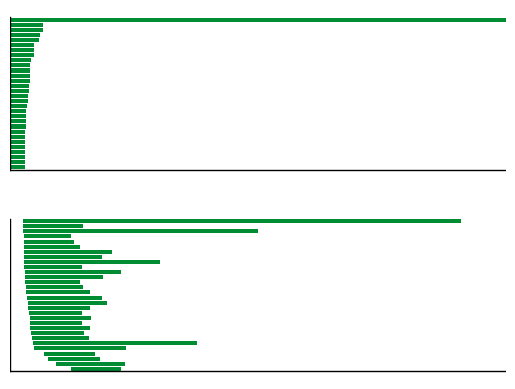

Results directory already created


In [9]:
dim_red_spikes_move_scaled,__,__ = pca(preprocessing.scale(sspikes[movetimes,:]), dim = dim)
indstemp,dd,fs  = sample_denoising(dim_red_spikes_move_scaled,  k,
                                        n_points, 1, metric)
dim_red_spikes_move_scaled = dim_red_spikes_move_scaled[indstemp,:]
X = squareform(pdist(dim_red_spikes_move_scaled, metric))
knn_indices = np.argsort(X)[:, :nbs]
knn_dists = X[np.arange(X.shape[0])[:, None], knn_indices].copy()
sigmas, rhos = smooth_knn_dist(knn_dists, nbs, local_connectivity=0)
rows, cols, vals = compute_membership_strengths(knn_indices, knn_dists, sigmas, rhos)
result = coo_matrix((vals, (rows, cols)), shape=(X.shape[0], X.shape[0]))
result.eliminate_zeros()
transpose = result.transpose()
prod_matrix = result.multiply(transpose)
result = (result + transpose - prod_matrix)
result.eliminate_zeros()
d = result.toarray()
d = -np.log(d)
np.fill_diagonal(d,0)

persistence = ripser(d, maxdim=maxdim, coeff=coeff, do_cocycles= True, distance_matrix = True)
plot_barcode(persistence['dgms'])

#if len(day)>0:
#        day = '_' + day
print(rat + '_' + mod + '_' + exp + day)
plt.show()

try:
    os.mkdir(data_folder + 'Results')
except:
    print('Results directory already created')
np.savez_compressed(data_folder + 'Results/' + rat + '_' + mod + '_' + exp + day + '_persistence', persistence = persistence, indstemp = indstemp,  movetimes = movetimes)
#day = day[1:]

In [10]:
############ Decode cocycles ################
diagrams = persistence["dgms"] # the multiset describing the lives of the persistence classes
cocycles = persistence["cocycles"][1] # the cocycle representatives for the 1-dim classes
dists_land = persistence["dperm2all"] # the pairwise distance between the points
births1 = diagrams[1][:, 0] #the time of birth for the 1-dim classes
deaths1 = diagrams[1][:, 1] #the time of death for the 1-dim classes
deaths1[np.isinf(deaths1)] = 0
lives1 = deaths1-births1 # the lifetime for the 1-dim classes
iMax = np.argsort(lives1)
coords1 = np.zeros((num_circ, len(indstemp)))
threshold = births1[iMax[-2]] + (deaths1[iMax[-2]] - births1[iMax[-2]])*dec_tresh
for c in ph_classes:
    cocycle = cocycles[iMax[-(c+1)]]
    coords1[c,:],inds = get_coords(cocycle, threshold, len(indstemp), dists_land, coeff)

num_neurons = len(sspikes[0,:])
centcosall = np.zeros((num_neurons, 2, n_points))
centsinall = np.zeros((num_neurons, 2, n_points))
dspk = preprocessing.scale(sspikes[movetimes[indstemp],:])

for neurid in range(num_neurons):
    spktemp = dspk[:, neurid].copy()
    centcosall[neurid,:,:] = np.multiply(np.cos(coords1[:, :]*2*np.pi),spktemp)
    centsinall[neurid,:,:] = np.multiply(np.sin(coords1[:, :]*2*np.pi),spktemp)

In [11]:
#day = 'day1'
if exp in ('OF', 'WW'):
    sspikes,xx,yy,aa,tt = get_spikes(rat, mod, day, exp, bType = 'pure',
                                         bSmooth = True, bSpeed = True, smoothing_width = sigma, folder = data_folder)
    spikes,__,__,__,__ = get_spikes(rat, mod, day, exp, bType = 'pure',
                                         bSmooth = False, bSpeed = True, folder = data_folder)
else:
    sspikes = get_spikes(rat, mod, day, exp, bType = 'pure', bSmooth = True, bSpeed = False,
                             smoothing_width = sigma, folder = data_folder)
    spikes = get_spikes(rat, mod, day, exp, bType = 'pure', bSmooth = False, bSpeed = False,
                            folder = data_folder)

times = np.where(np.sum(spikes>0, 1)>=1)[0]
dspk = preprocessing.scale(sspikes)
sspikes = sspikes[times,:]
dspk = dspk[times,:]

a = np.zeros((len(sspikes[:,0]), 2, num_neurons))
for n in range(num_neurons):
    a[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centcosall[n,:,:],1))

c = np.zeros((len(sspikes[:,0]), 2, num_neurons))
for n in range(num_neurons):
    c[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centsinall[n,:,:],1))

mtot2 = np.sum(c,2)
mtot1 = np.sum(a,2)
coords = np.arctan2(mtot2,mtot1)%(2*np.pi)
#if exp == 'OF':
coordsbox = coords.copy()
times_box = times.copy()
#else:
#    sspikes,xx,yy,aa,tt = get_spikes(rat, mod, day, 'OF', bType = 'pure',
#                                         bSmooth = True, bSpeed = True, smoothing_width = sigma, folder = data_folder)
#    spikes,__,__,__,__ = get_spikes(rat, mod, day, 'OF', bType = 'pure',
#                                         bSmooth = False, bSpeed = True, folder = data_folder)
#    dspk =preprocessing.scale(sspikes)
#    times_box = np.where(np.sum(spikes>0, 1)>=1)[0]
#    dspk = dspk[times_box,:]
#
#    a = np.zeros((len(times_box), 2, num_neurons))
#    for n in range(num_neurons):
#        a[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centcosall[n,:,:],1))
#
#    c = np.zeros((len(times_box), 2, num_neurons))
#    for n in range(num_neurons):
#         c[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centsinall[n,:,:],1))
#
#    mtot2 = np.sum(c,2)
#    mtot1 = np.sum(a,2)
#    coordsbox = np.arctan2(mtot2,mtot1)%(2*np.pi)
if exp in ('OF', 'WW'):
    plot_times = np.arange(0, len(times_box), 10)
    plt.viridis()
    fig, ax = plt.subplots(1,2)
    ax[0].axis('off')
    ax[0].scatter(xx[times_box][plot_times], yy[times_box][plot_times], c = np.cos(coordsbox[plot_times,0]))
    ax[0].set_aspect('equal', 'box')

    ax[1].axis('off')
    ax[1].scatter(xx[times_box][plot_times], yy[times_box][plot_times], c = np.cos(coordsbox[plot_times,1]))
    ax[1].set_aspect('equal', 'box')

#if len(day)>0:
#    day = '_' + day
np.savez_compressed(data_folder + 'Results//' +
                    rat + '_' + mod + '_' + exp + day + '_decoding',
                    coords = coords, coordsbox = coordsbox,  times = times,
                    times_box = times_box, centcosall = centcosall, centsinall = centsinall)

In [12]:
if exp in ('OF', 'WW'):
    fig = plt.figure(figsize = (8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(coordsbox[500:1000, 0], coordsbox[500:1000, 1], 'ko-')
    plt.subplot(1, 2, 2)
    plt.plot(xx[500:1000], yy[500:1000], 'ko-')
    plt.axis((-0.75, 0.75, -0.75, 0.75))

Text(0.5, 0.98, 'Predictive cells')

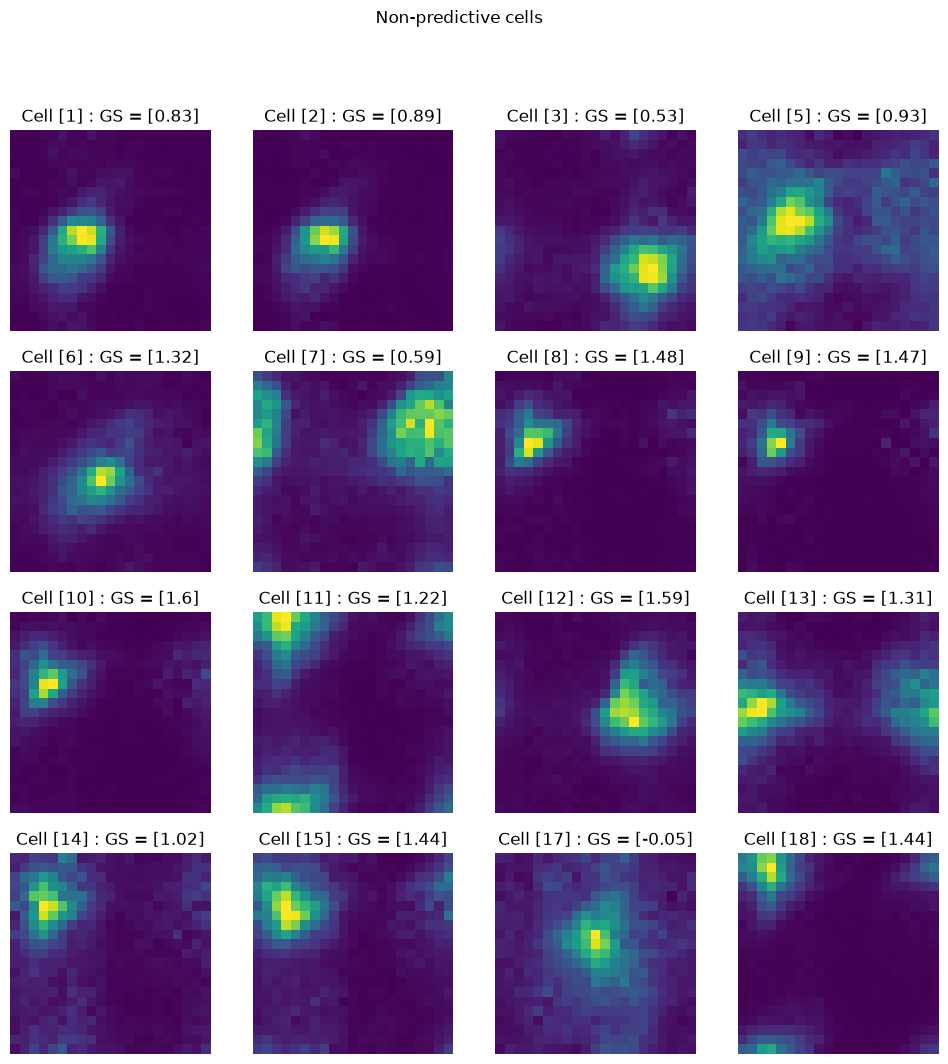

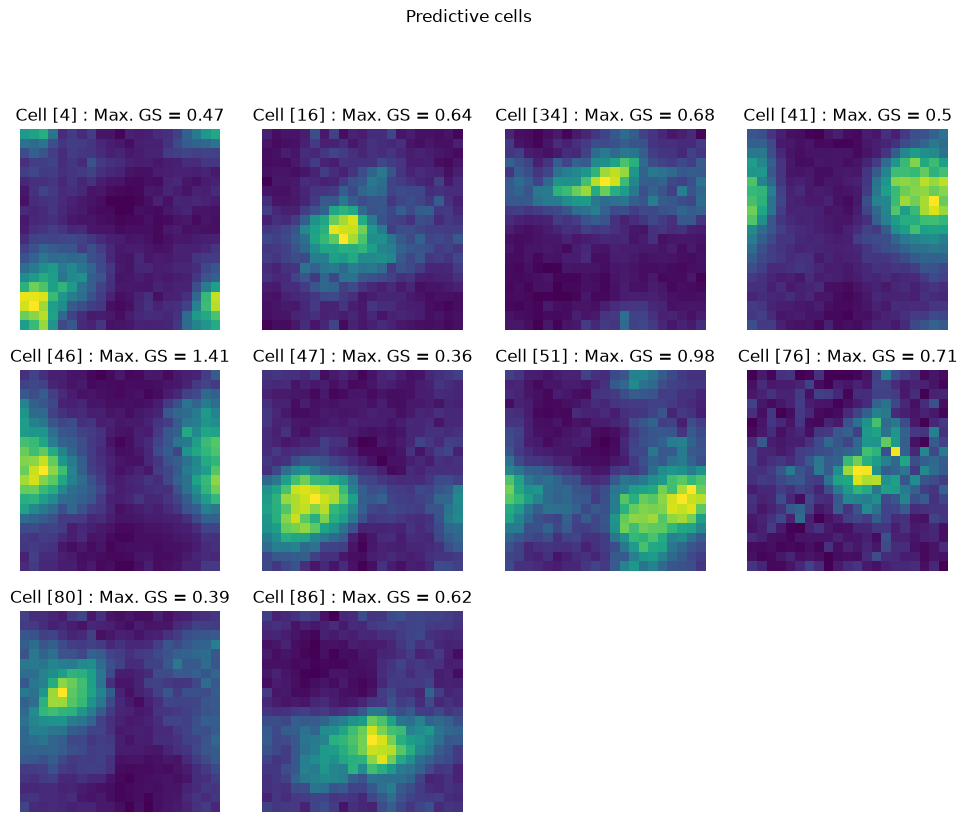

In [13]:
# Visualizing toroidal manifold rate-maps
torus_0 = coordsbox[:, 0]
torus_1 = coordsbox[:, 1]

n_torus_bins = 20
torus_0_binned = np.round((torus_0 - np.min(torus_0)) / (np.max(torus_0) - np.min(torus_0)) * n_torus_bins)
torus_1_binned = np.round((torus_1 - np.min(torus_1)) / (np.max(torus_1) - np.min(torus_1)) * n_torus_bins)

torus_ratemaps = np.zeros((len(non_conjunctive_cells), n_torus_bins + 1, n_torus_bins + 1))
torus_occupancy = np.zeros((n_torus_bins + 1, n_torus_bins + 1))
for t in range(len(torus_0_binned)):
    torus_ratemaps[:, int(torus_0_binned[t]), int(torus_1_binned[t])] += sspikes[t, :]
    torus_occupancy[int(torus_0_binned[t]), int(torus_1_binned[t])] += 1

torus_ratemaps = torus_ratemaps / torus_occupancy

n_cells_plot = 16
n_x = int(np.round(np.sqrt(n_cells_plot)))
n_y = int(np.ceil(np.sqrt(n_cells_plot)))

cell_id = 0
non_pred_plotted = 0
plt.figure(figsize = (3 * n_x, 3 * n_y))
while non_pred_plotted < n_cells_plot and cell_id < num_neurons:
    if len(np.intersect1d(non_conjunctive_cells[cell_id], temporal_predictive_grid_cells)) == 0:
        plt.subplot(n_x, n_y, non_pred_plotted + 1)
        plt.imshow(torus_ratemaps[cell_id, :, :])
        plt.axis('off')
        plt.title('Cell ' + str(non_conjunctive_cells[cell_id]) + ' : GS = ' + str(np.round(temporal_grid_scores[temporal_idx0, non_conjunctive_cells[cell_id]], 2)))
        non_pred_plotted += 1
    cell_id += 1
plt.suptitle('Non-predictive cells')

cell_id = 0
pred_plotted = 0
plt.figure(figsize = (3 * n_x, 3 * n_y))
while pred_plotted < n_cells_plot and cell_id < num_neurons:
    if len(np.intersect1d(non_conjunctive_cells[cell_id], temporal_predictive_grid_cells)) == 1:
        plt.subplot(n_x, n_y, pred_plotted + 1)
        plt.imshow(torus_ratemaps[cell_id, :, :])
        plt.axis('off')
        plt.title('Cell ' + str(non_conjunctive_cells[cell_id]) + ' : Max. GS = ' + str(np.round(np.max(temporal_grid_scores[:, non_conjunctive_cells[cell_id]]), 2)))
        pred_plotted += 1
    cell_id += 1
plt.suptitle('Predictive cells')

In [22]:
temporal_shifts = np.arange(-40, 40, 2)
n_shifts = len(temporal_shifts)
temporal_idx0 = np.argwhere(temporal_shifts == 0)
torus_ratemaps_shifted = np.zeros((len(non_conjunctive_cells), n_torus_bins + 1, n_torus_bins + 1, len(temporal_shifts)))
spatial_info_shifted = np.zeros((len(non_conjunctive_cells), len(temporal_shifts)))

for s in range(len(temporal_shifts)):
    torus_occupancy = np.zeros((n_torus_bins + 1, n_torus_bins + 1))

    if temporal_shifts[s] < 0:
        torus_0_binned_shifted = torus_0_binned[:temporal_shifts[s]]
        torus_1_binned_shifted = torus_1_binned[:temporal_shifts[s]]
        sspikes_shifted = sspikes[-temporal_shifts[s]:, :]
    elif temporal_shifts[s] == 0:
        torus_0_binned_shifted = torus_0_binned
        torus_1_binned_shifted = torus_1_binned
        sspikes_shifted = sspikes
    else:
        torus_0_binned_shifted = torus_0_binned[temporal_shifts[s]:]
        torus_1_binned_shifted = torus_1_binned[temporal_shifts[s]:]
        sspikes_shifted = sspikes[:-temporal_shifts[s], :]

    for t in range(len(torus_0_binned_shifted)):
        torus_ratemaps_shifted[:, int(torus_0_binned_shifted[t]), int(torus_1_binned_shifted[t]), s] += sspikes_shifted[t, :]
        torus_occupancy[int(torus_0_binned_shifted[t]), int(torus_1_binned_shifted[t])] += 1

    torus_ratemaps_shifted[:, :, :, s] = torus_ratemaps_shifted[:, :, :, s] / torus_occupancy

    for i in range(len(non_conjunctive_cells)):
        X = torus_ratemaps_shifted[i, :, :, s]
        mean_X = np.nanmean(X)
        si = np.nansum(torus_occupancy/np.sum(torus_occupancy) * X * np.log2(X / mean_X)) / mean_X
        spatial_info_shifted[i, s] = si


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_57211/3103146945.py:32: RuntimeWarning: divide by zero encountered in log2
  si = np.nansum(torus_occupancy/np.sum(torus_occupancy) * X * np.log2(X / mean_X)) / mean_X
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_57211/3103146945.py:32: RuntimeWarning: invalid value encountered in multiply
  si = np.nansum(torus_occupancy/np.sum(torus_occupancy) * X * np.log2(X / mean_X)) / mean_X


In [23]:
import copy
spatial_info_shifted_norm = copy.deepcopy(spatial_info_shifted)
for i in range(num_neurons):
    spatial_info_shifted_norm[i, :] = spatial_info_shifted_norm[i, :] / spatial_info_shifted_norm[i, temporal_idx0]

[1.    0.42  0.42  0.42  0.21  0.682 0.682 0.42  0.21  0.21  0.21  0.42
 0.21  0.084 0.006 0.006 0.42  0.682 0.909 0.909]
[1.    0.827 0.653 0.653 0.744 0.827 0.56  0.383 0.238 0.134 0.238 0.181
 0.069 0.097 0.134 0.383 0.305 0.047 0.021 0.005]


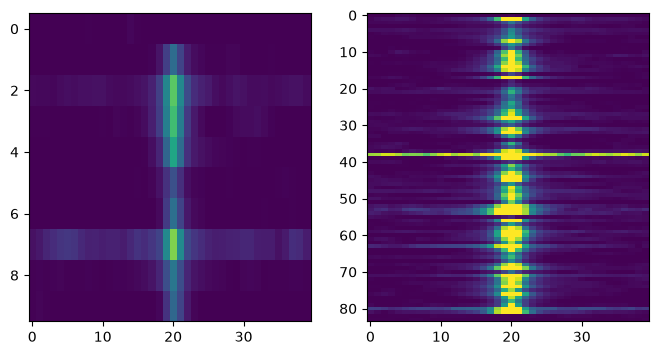

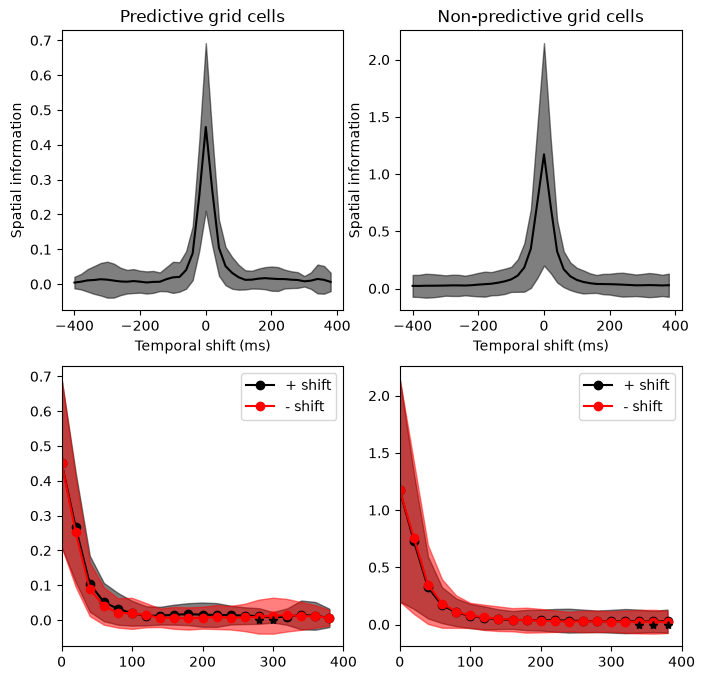

In [24]:
_, predictive_ids, _ = np.intersect1d(non_conjunctive_cells, temporal_predictive_grid_cells, return_indices=True)
non_predictive_mask = ~np.isin(np.arange(0, num_neurons, 1), predictive_ids)
non_predictive_ids = np.arange(0, num_neurons, 1)[non_predictive_mask]
predictive_si = spatial_info_shifted[predictive_ids, :]
predictive_si_sorted = predictive_si[np.argsort(np.argmax(predictive_si, axis = 1)), :]
non_predictive_si = spatial_info_shifted[non_predictive_ids, :]
non_predictive_si_sorted = non_predictive_si[np.argsort(np.argmax(non_predictive_si, axis = 1)), :]

fig = plt.figure(figsize = (8, 4))
plt.subplot(1, 2, 1)
plt.imshow(predictive_si_sorted, aspect ='auto')
plt.clim(0, 1)
plt.subplot(1, 2, 2)
plt.imshow(non_predictive_si_sorted, aspect = 'auto')
plt.clim(0, 1)

 # Mean spatial info vs. shift
fig = plt.figure(figsize = (8, 8))
plt.subplot(2, 2, 1)
plt.fill_between(10 * temporal_shifts, np.mean(predictive_si_sorted, axis = 0) - np.std(predictive_si_sorted, axis = 0), np.mean(predictive_si_sorted, axis = 0) + np.std(predictive_si_sorted, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(predictive_si_sorted, axis = 0), 'k-')
plt.xlabel('Temporal shift (ms)')
plt.ylabel('Spatial information')
plt.title('Predictive grid cells')

plt.subplot(2, 2, 2)
plt.fill_between(10 * temporal_shifts, np.mean(non_predictive_si_sorted, axis = 0) - np.std(non_predictive_si_sorted, axis = 0), np.mean(non_predictive_si_sorted, axis = 0) + np.std(non_predictive_si_sorted, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(non_predictive_si_sorted, axis = 0), 'k-')
plt.xlabel('Temporal shift (ms)')
plt.ylabel('Spatial information')
plt.title('Non-predictive grid cells')

p_values_predictive = np.zeros(int(np.floor(n_shifts / 2)))
for s in range(int(np.floor(n_shifts / 2))):
    p_values_predictive[s] = scipy.stats.kstest(predictive_si_sorted[:, int(temporal_idx0[0][0]) + s], predictive_si_sorted[:, int(temporal_idx0[0][0]) - s], alternative = 'less').pvalue
print(np.round(p_values_predictive, 3))

plt.subplot(2, 2, 3)
plt.fill_between(10 * temporal_shifts, np.mean(predictive_si_sorted, axis = 0) - np.std(predictive_si_sorted, axis = 0), np.mean(predictive_si_sorted, axis = 0) + np.std(predictive_si_sorted, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(predictive_si_sorted, axis = 0), 'ko-', label = '+ shift')
plt.fill_between(10 * temporal_shifts[1:], np.flip((np.mean(predictive_si_sorted, axis = 0) - np.std(predictive_si_sorted, axis = 0)))[:-1], np.flip((np.mean(predictive_si_sorted, axis = 0) + np.std(predictive_si_sorted, axis = 0)))[:-1], alpha = 0.5, color = 'r')
plt.plot(10 * temporal_shifts[1:], np.flip(np.mean(predictive_si_sorted, axis = 0))[:-1], 'ro-', label = '- shift')
for s in range(int(np.floor(n_shifts / 2))):
    if p_values_predictive[s] < 0.05:
        plt.plot(10 * temporal_shifts[temporal_idx0 + s], 0.0, 'k*')
plt.xlim(0, 400)
plt.legend()

p_values_non_predictive = np.zeros(int(np.floor(n_shifts / 2)))
for s in range(int(np.floor(n_shifts / 2))):
    p_values_non_predictive[s] = scipy.stats.kstest(non_predictive_si_sorted[:, int(temporal_idx0[0][0]) + s], non_predictive_si_sorted[:, int(temporal_idx0[0][0]) - s], alternative = 'less').pvalue
print(np.round(p_values_non_predictive, 3))

plt.subplot(2, 2, 4)
plt.fill_between(10 * temporal_shifts, np.mean(non_predictive_si_sorted, axis = 0) - np.std(non_predictive_si_sorted, axis = 0), np.mean(non_predictive_si_sorted, axis = 0) + np.std(non_predictive_si_sorted, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(non_predictive_si_sorted, axis = 0), 'ko-', label = '+ shift')
plt.fill_between(10 * temporal_shifts[1:], np.flip((np.mean(non_predictive_si_sorted, axis = 0) - np.std(non_predictive_si_sorted, axis = 0)))[:-1], np.flip((np.mean(non_predictive_si_sorted, axis = 0) + np.std(non_predictive_si_sorted, axis = 0)))[:-1], alpha = 0.5, color = 'r')
plt.plot(10 * temporal_shifts[1:], np.flip(np.mean(non_predictive_si_sorted, axis = 0))[:-1], 'ro-', label = '- shift')
for s in range(int(np.floor(n_shifts / 2))):
    if p_values_non_predictive[s] < 0.05:
        plt.plot(10 * temporal_shifts[temporal_idx0 + s], 0.0, 'k*')
plt.xlim(0, 400)
plt.legend()

plt.savefig(results_save_path + 'Mean_spatial_info_vs_shift_' + exp + '.png')
plt.savefig(results_save_path + 'Mean_spatial_info_vs_shift_' + exp + '.svg', format = 'svg')



<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:14: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:14: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_27864/3102894170.py

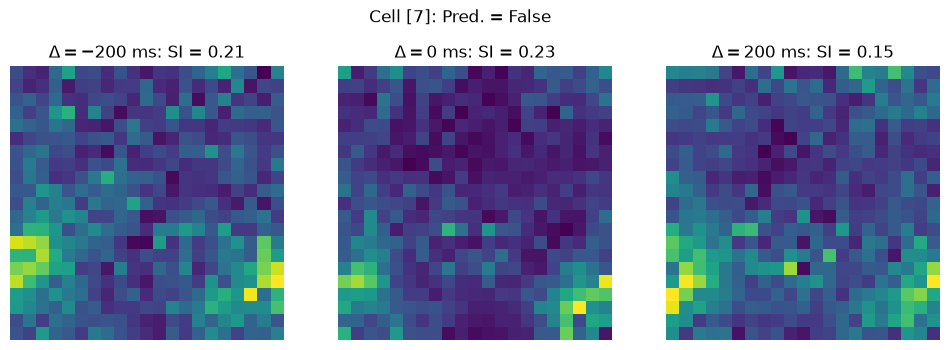

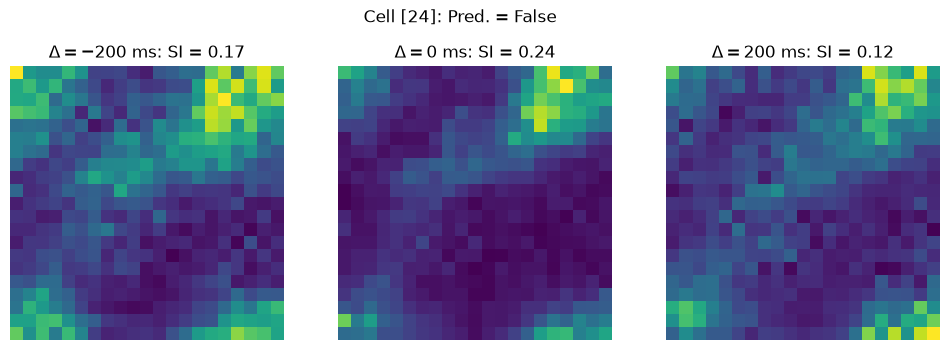

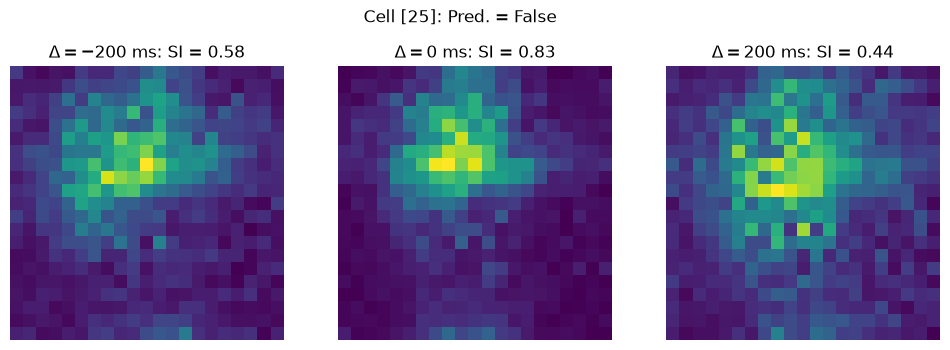

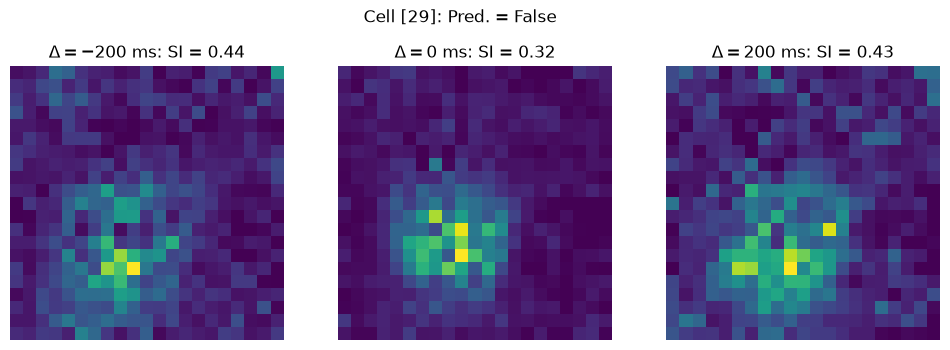

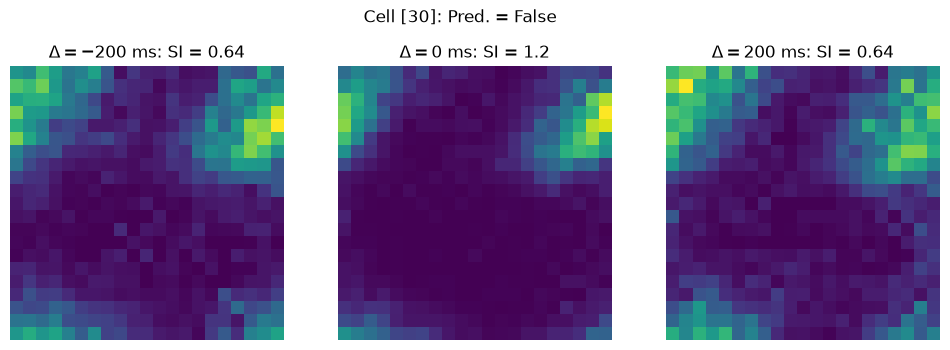

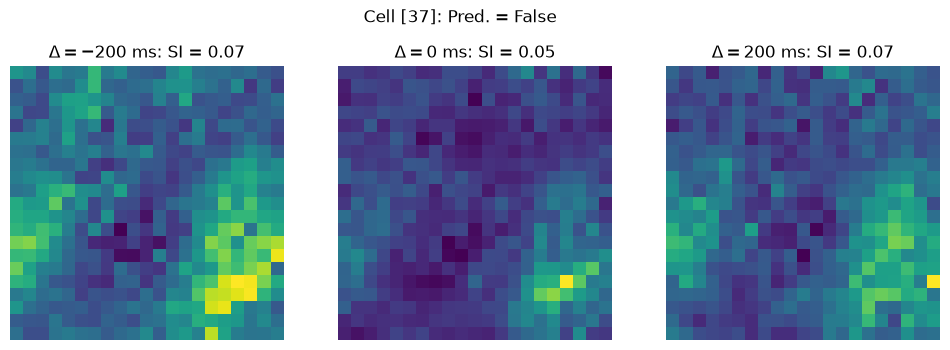

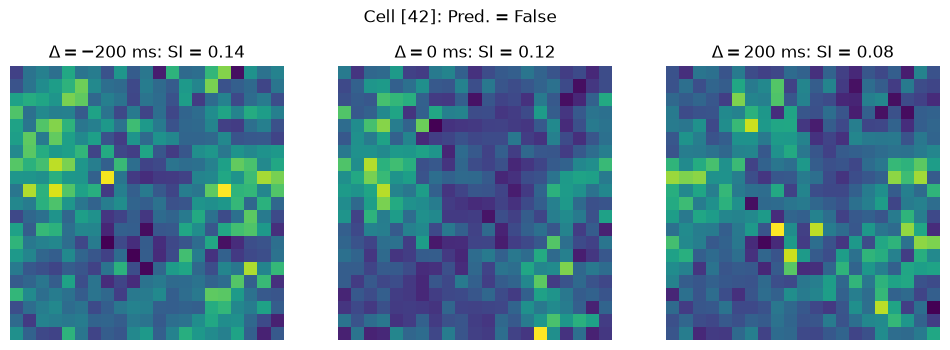

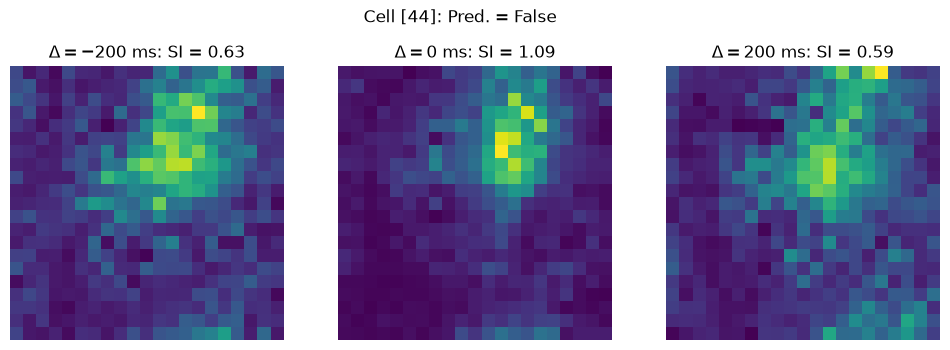

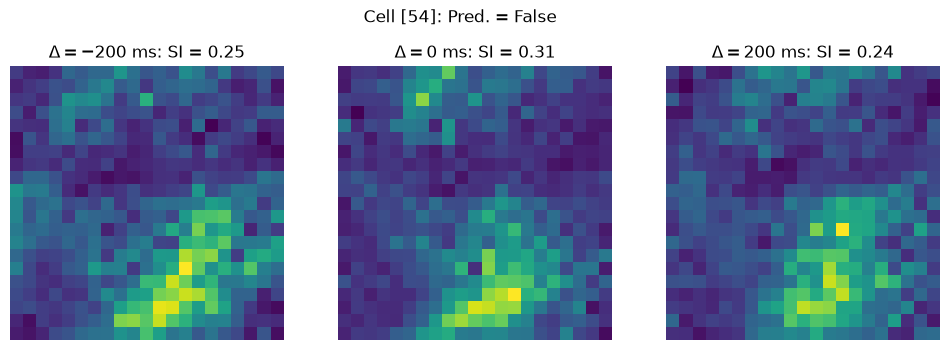

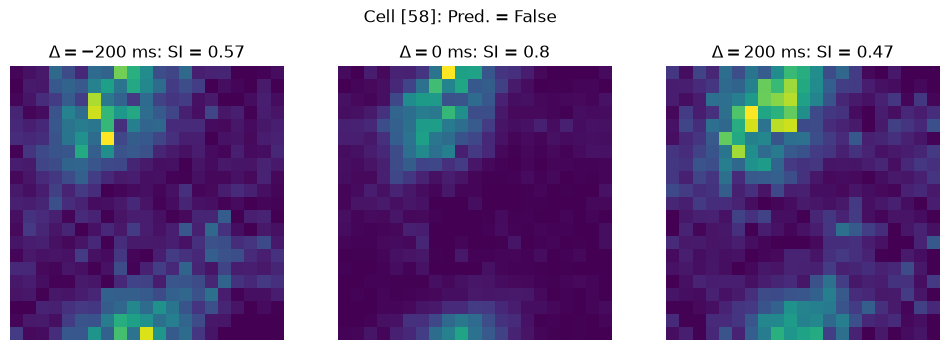

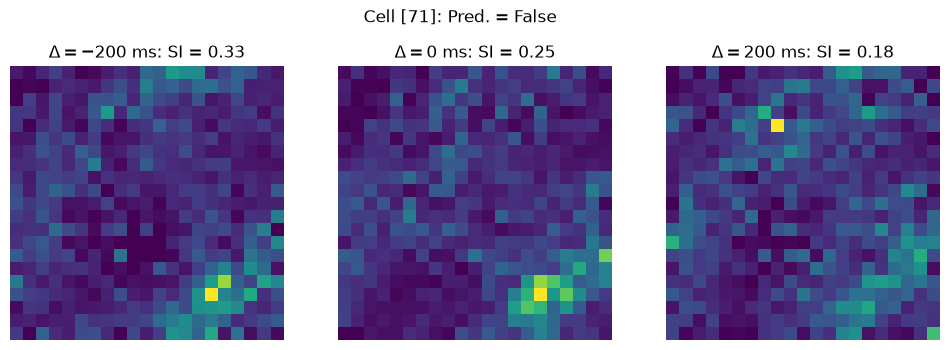

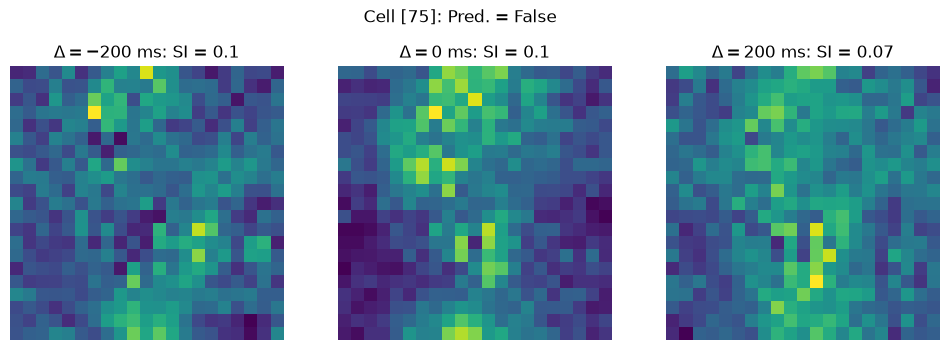

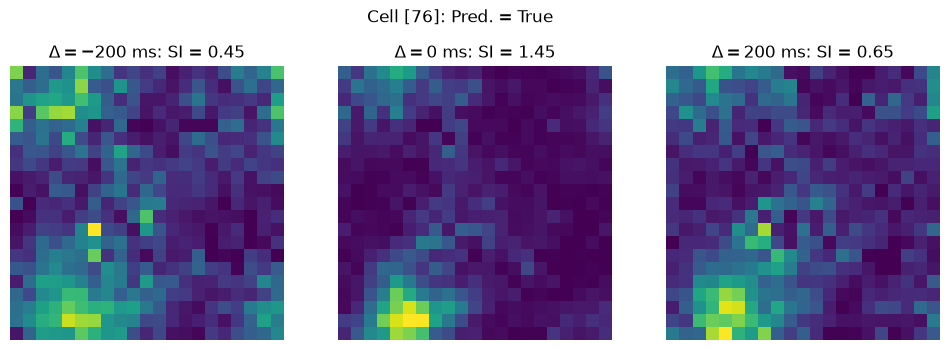

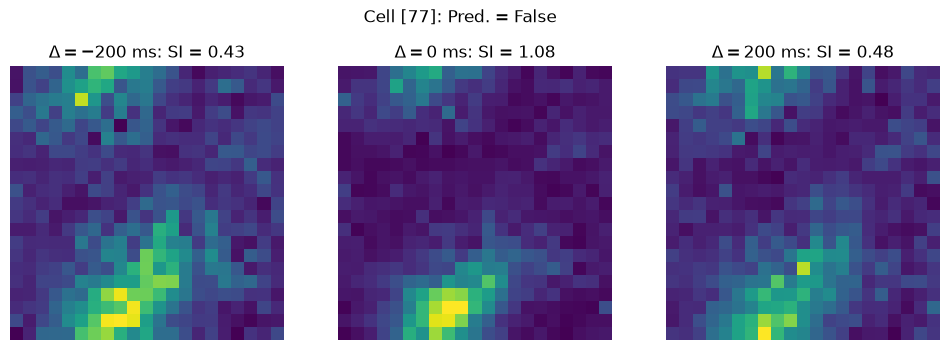

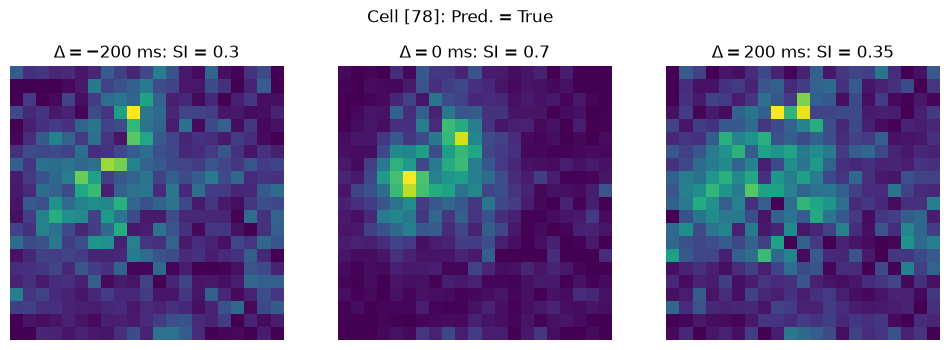

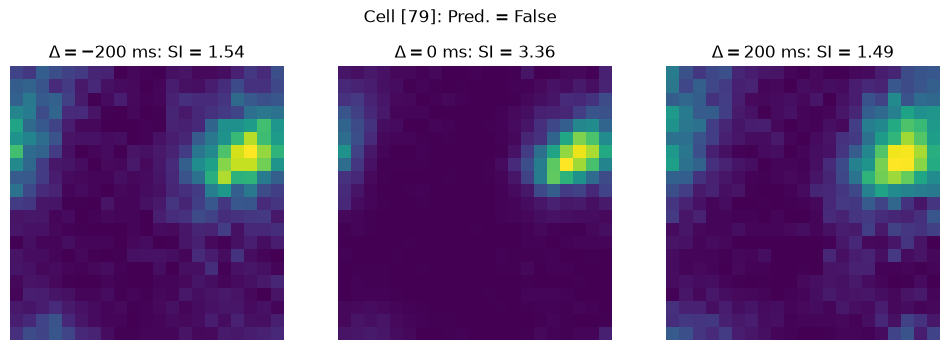

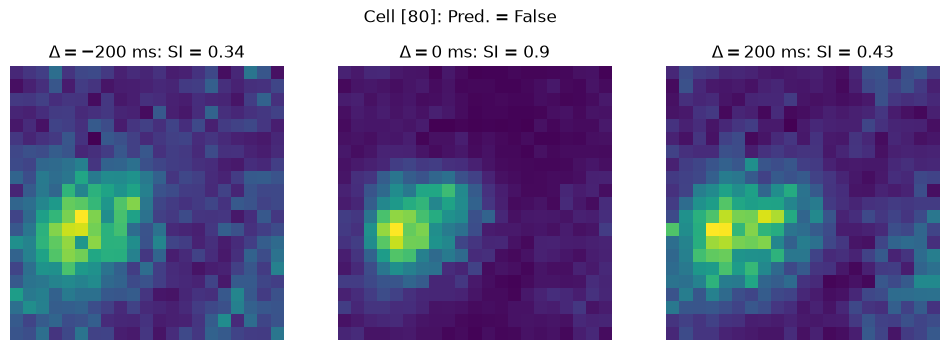

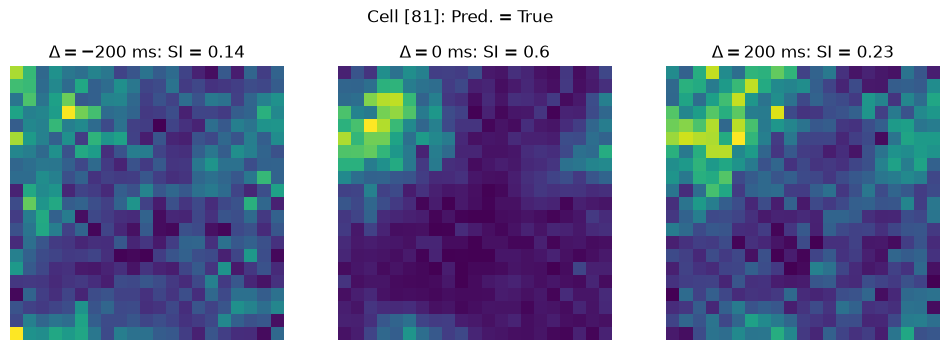

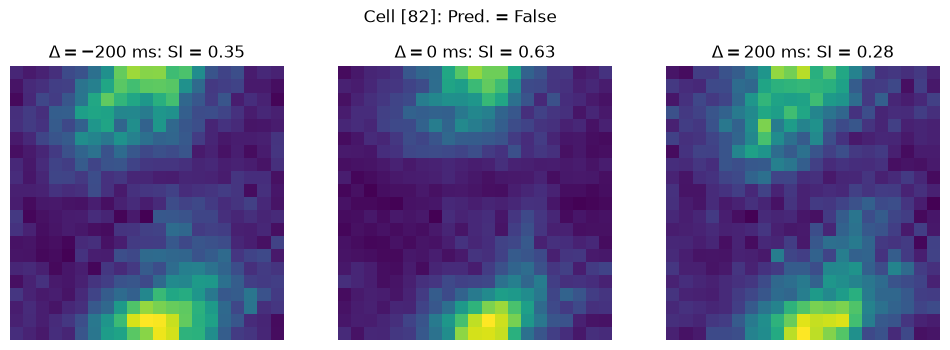

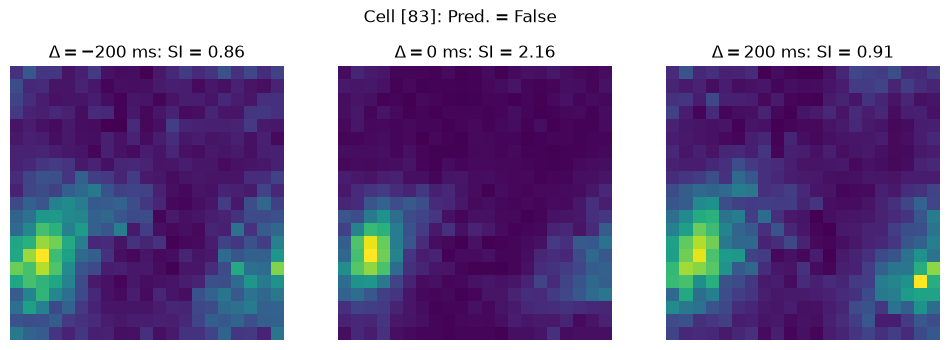

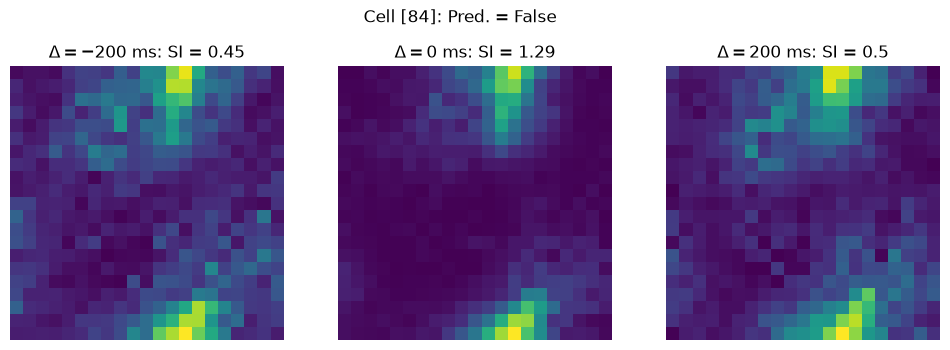

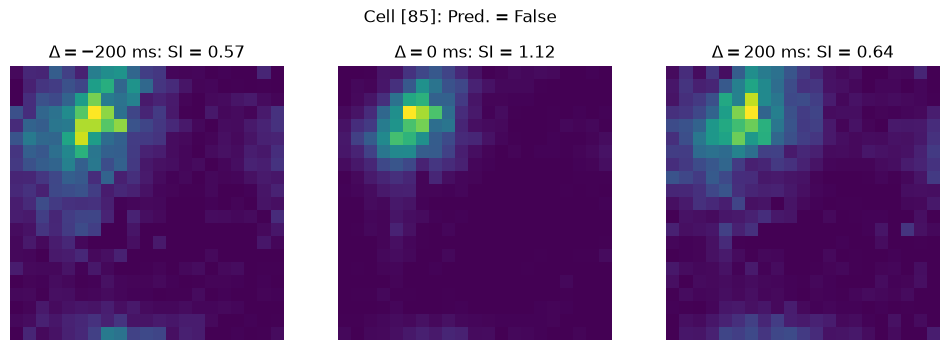

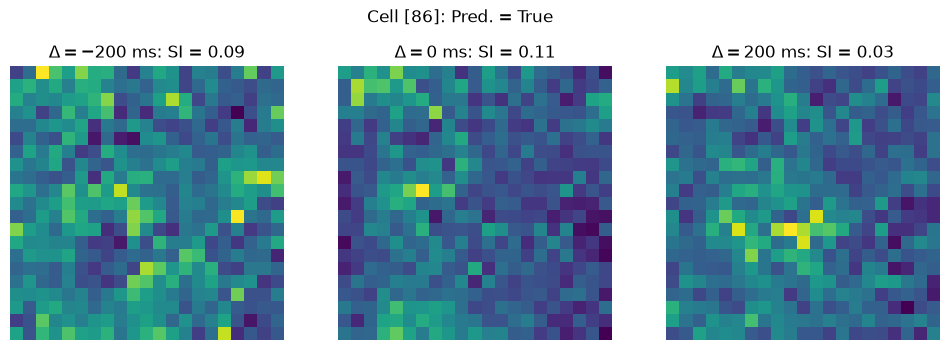

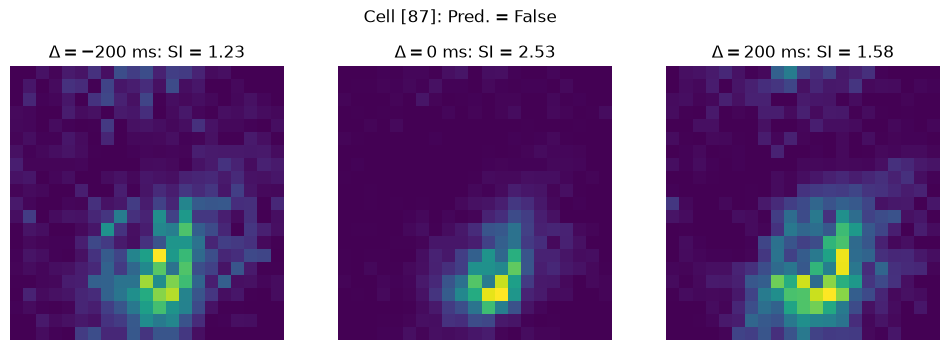

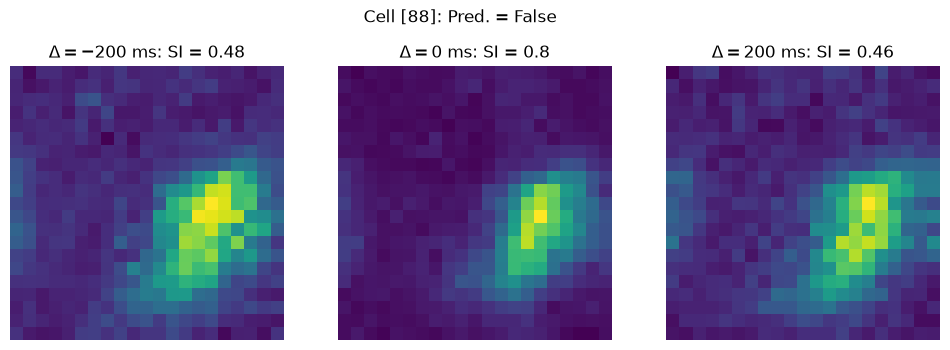

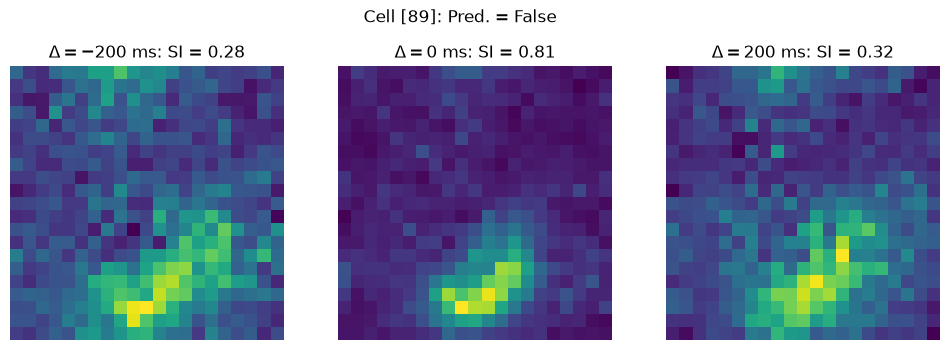

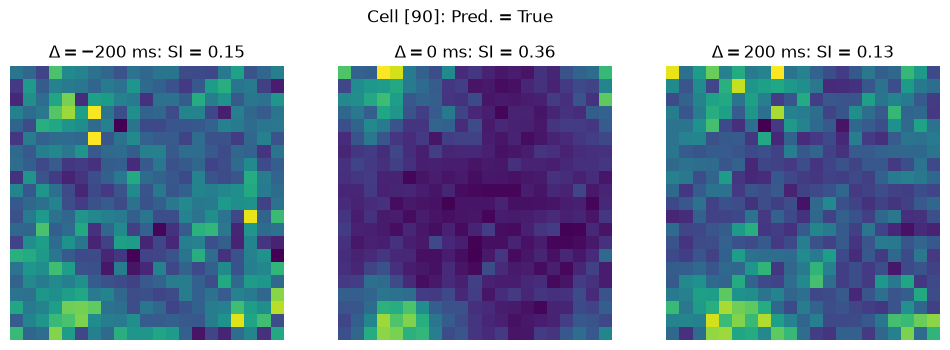

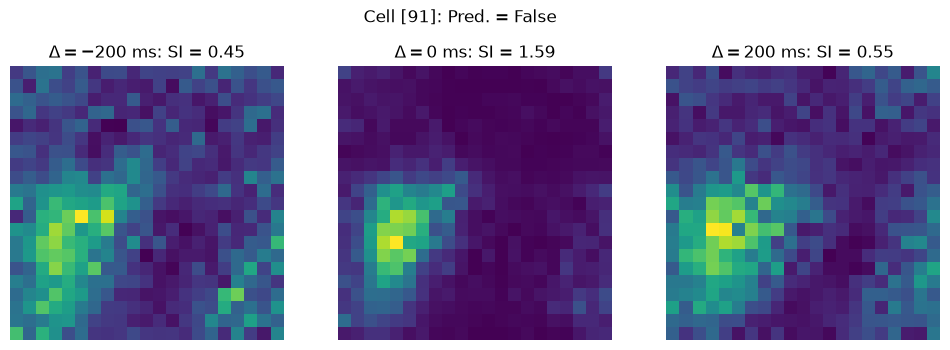

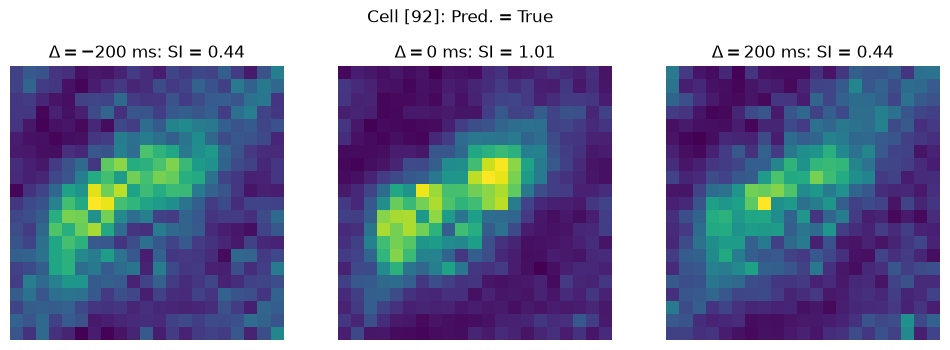

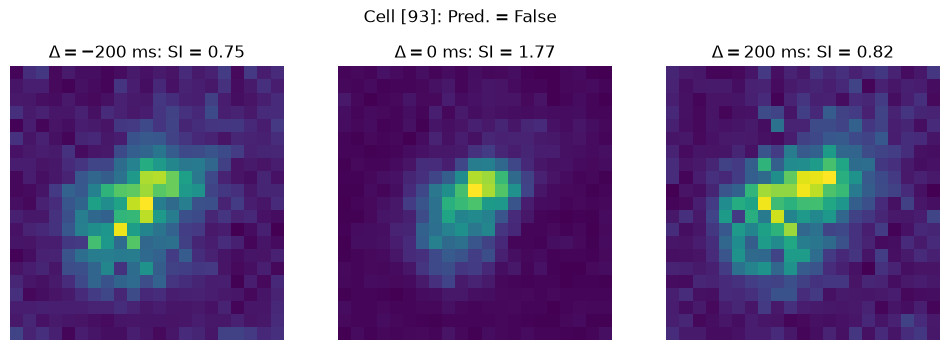

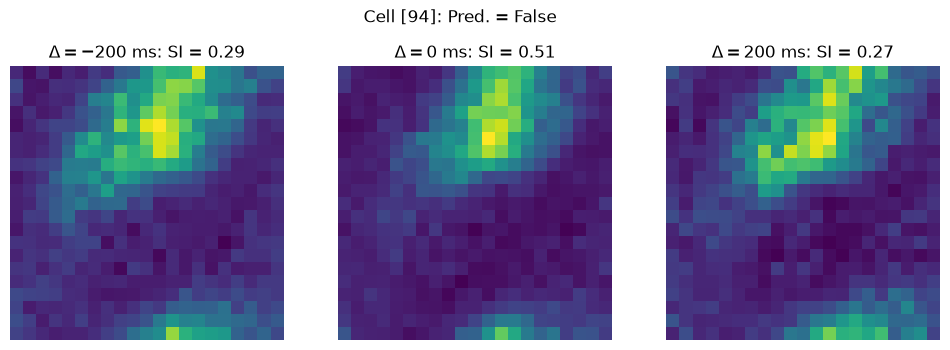

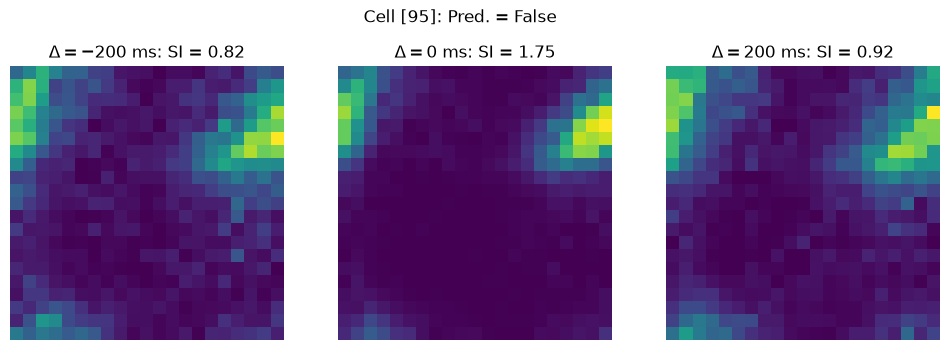

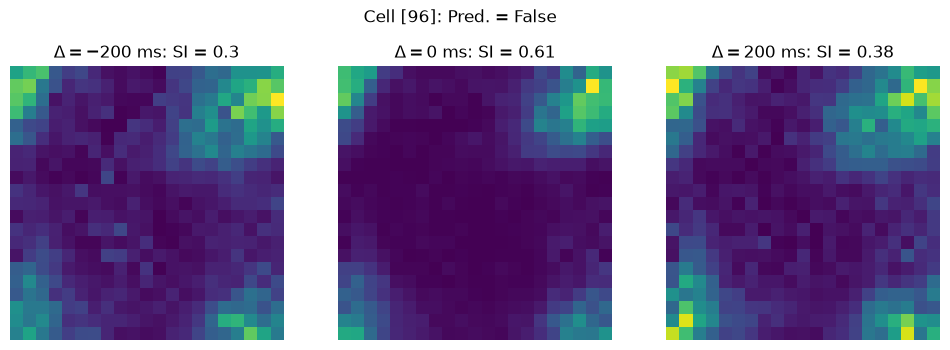

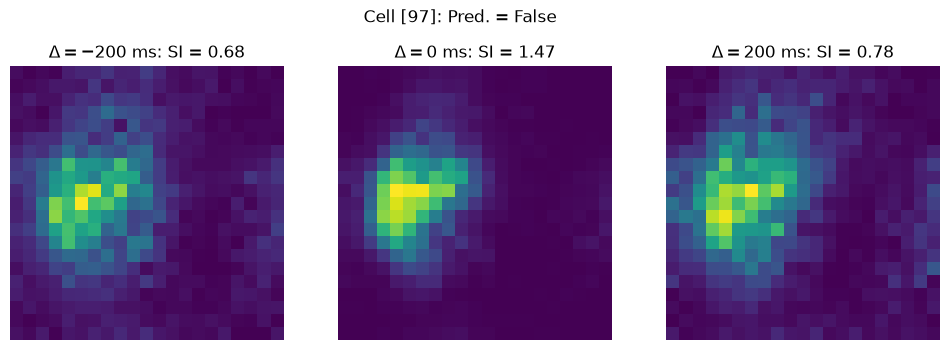

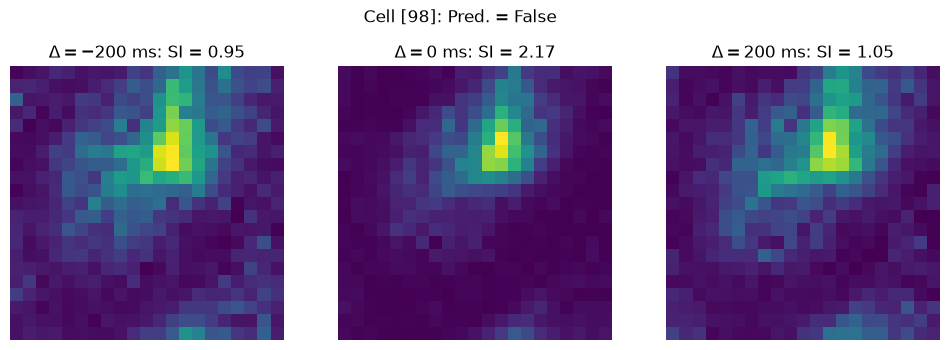

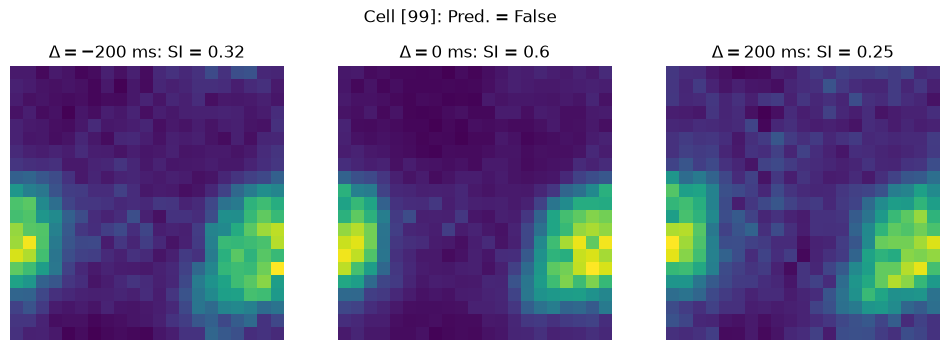

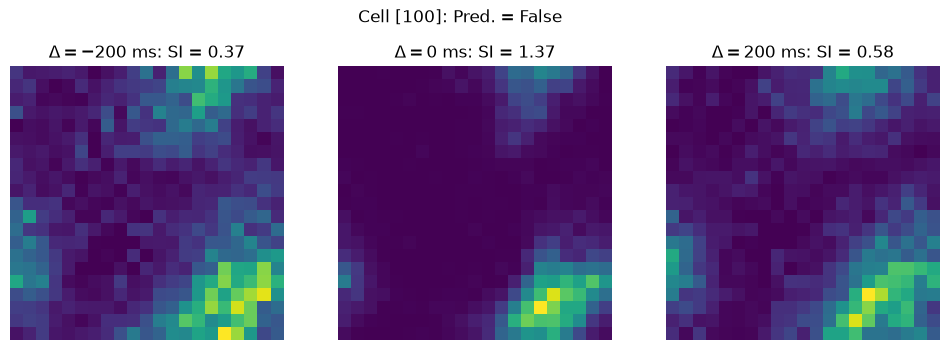

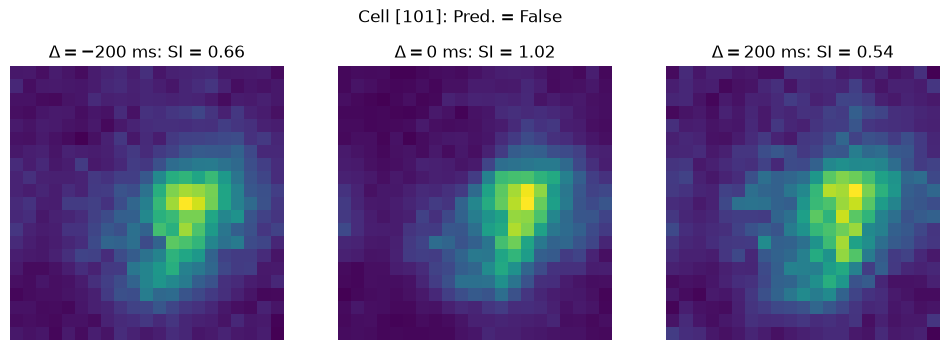

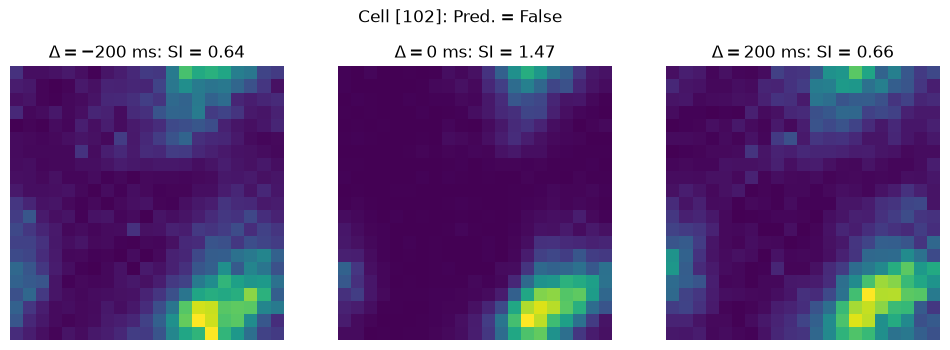

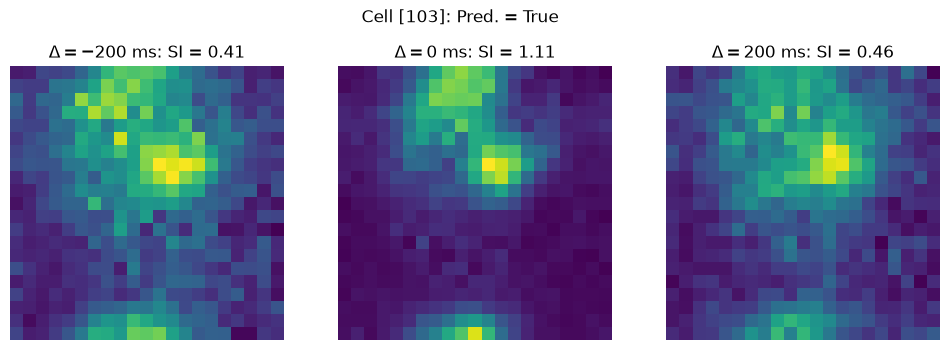

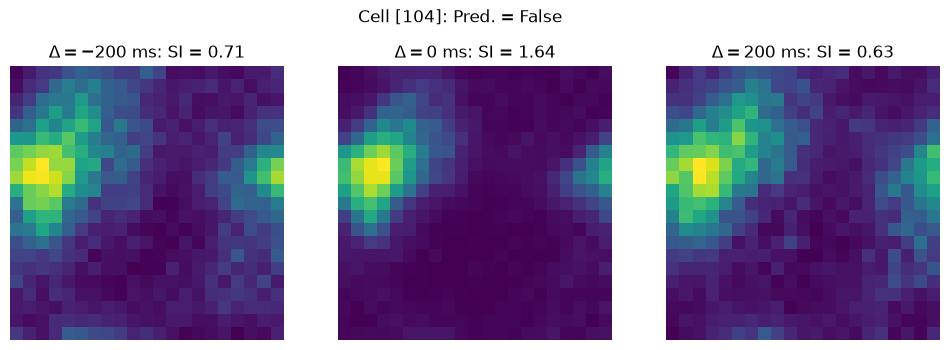

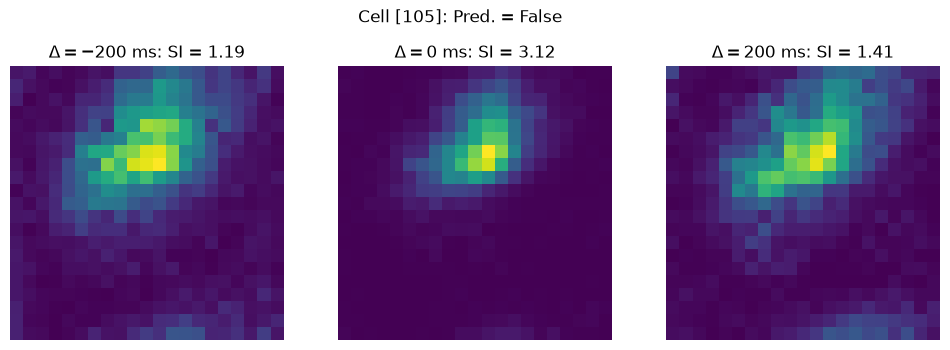

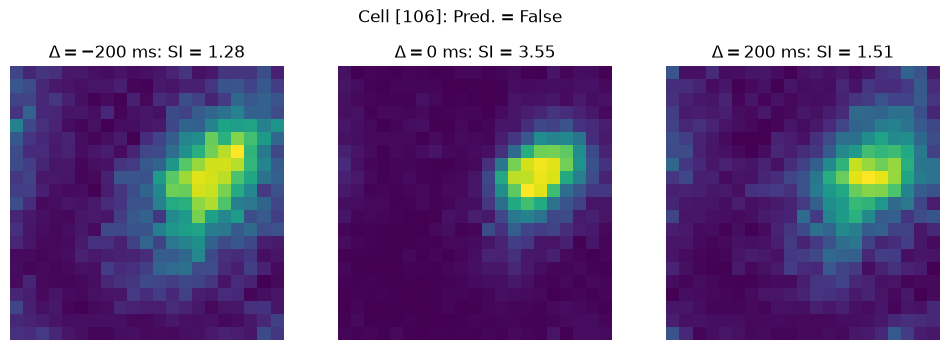

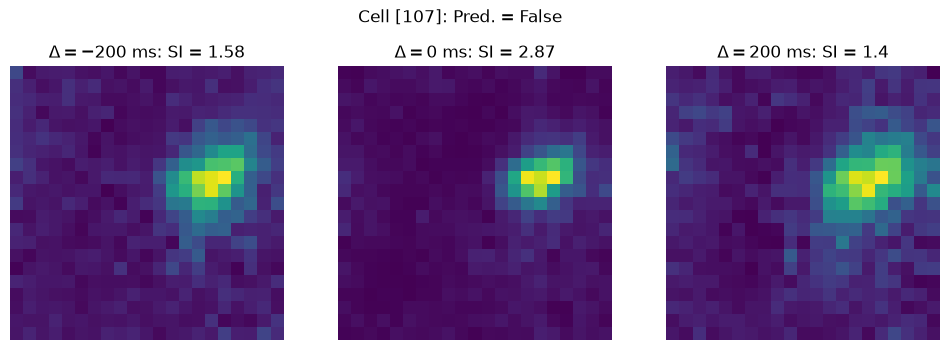

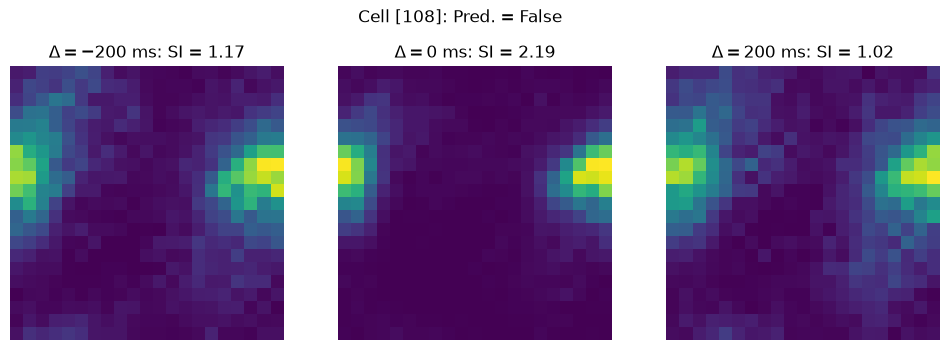

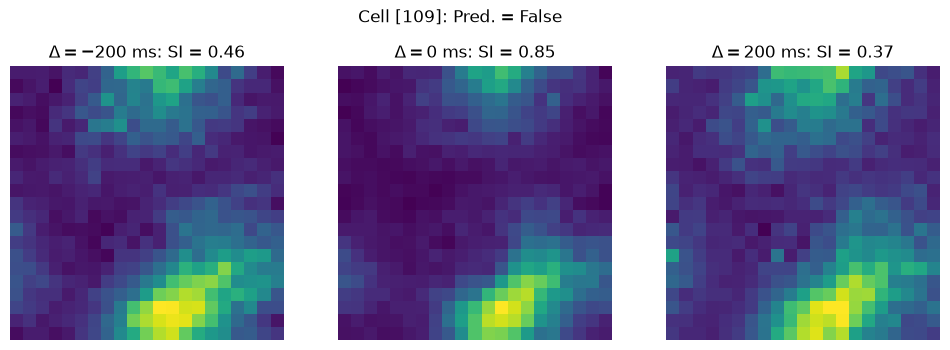

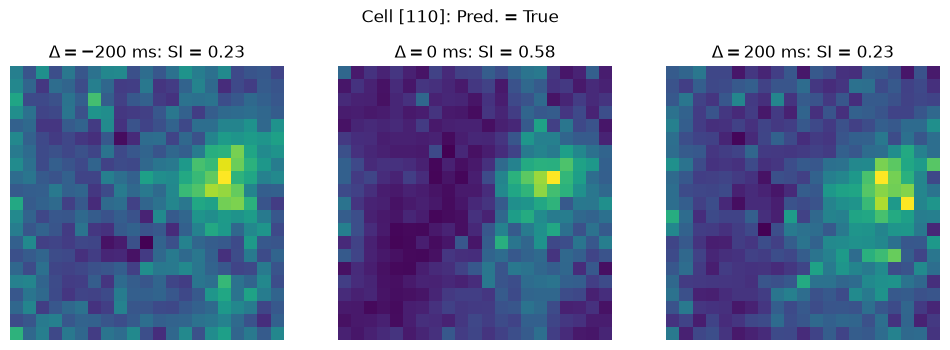

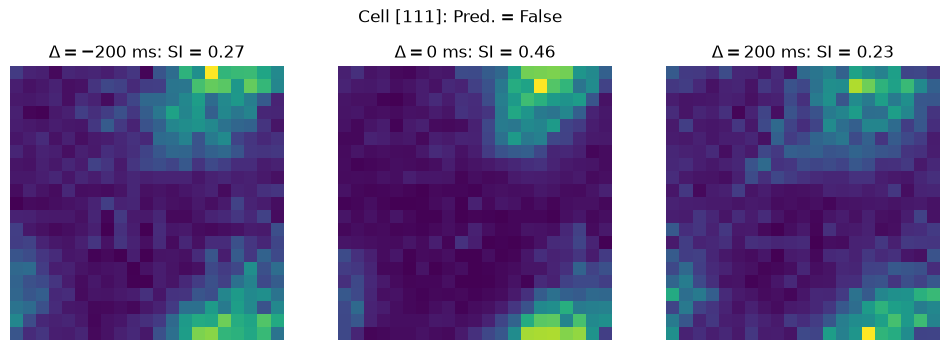

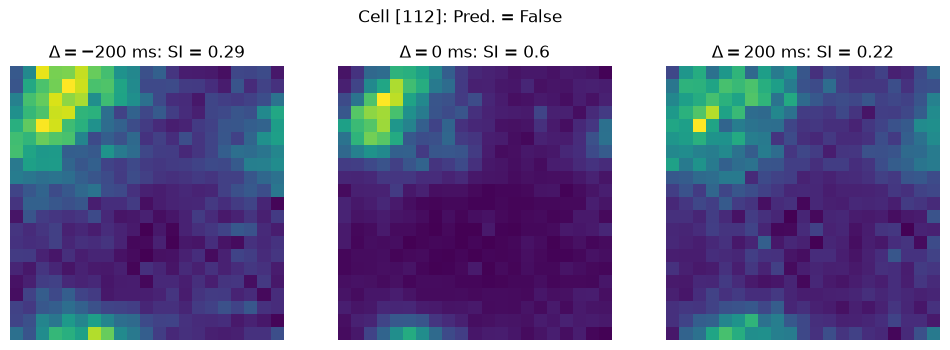

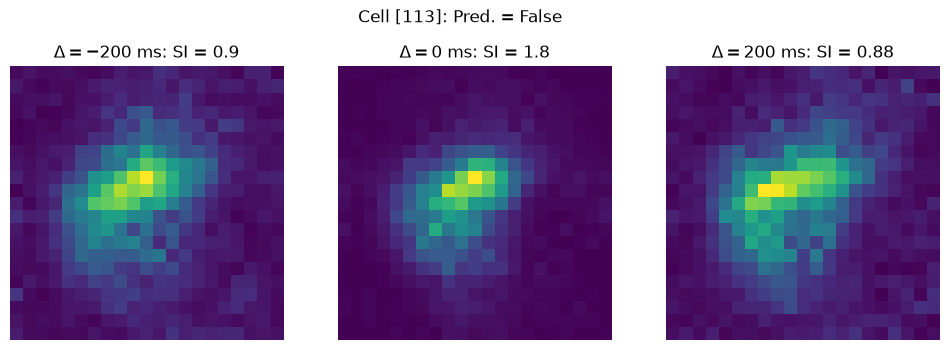

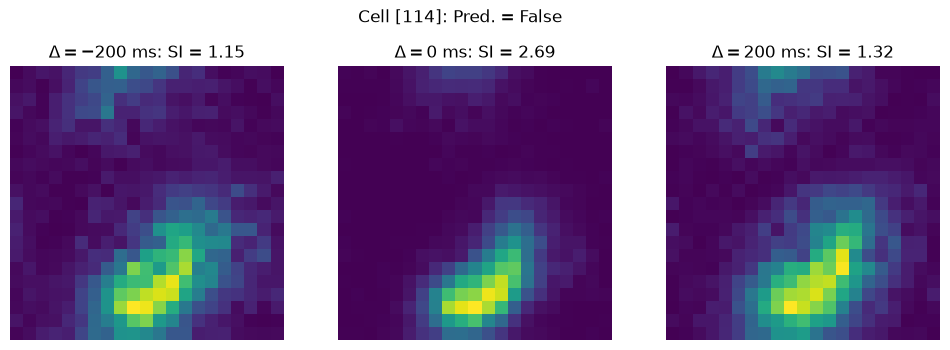

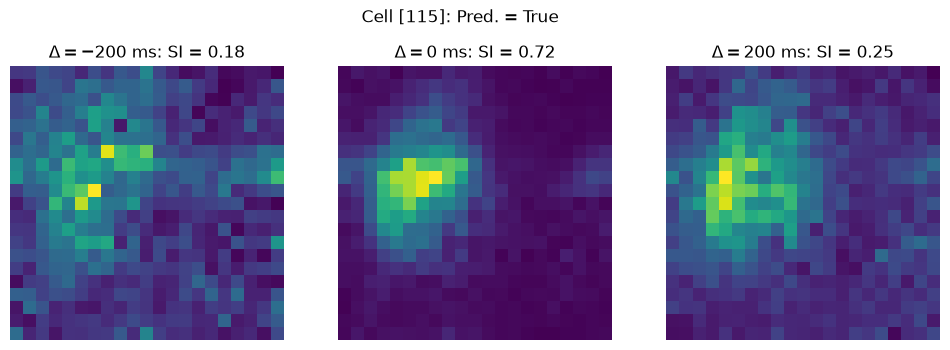

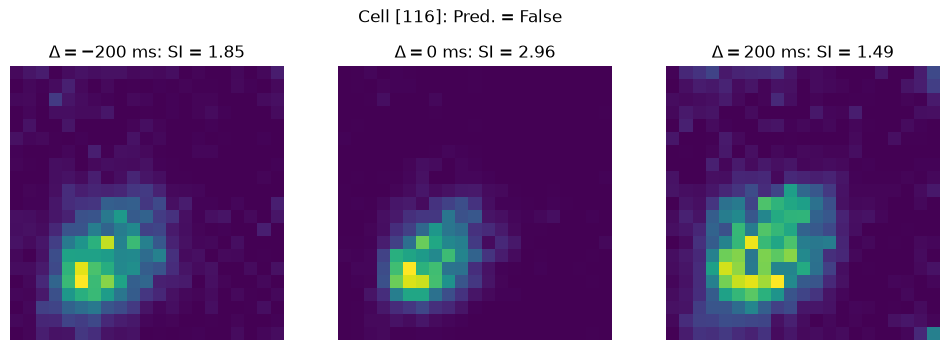

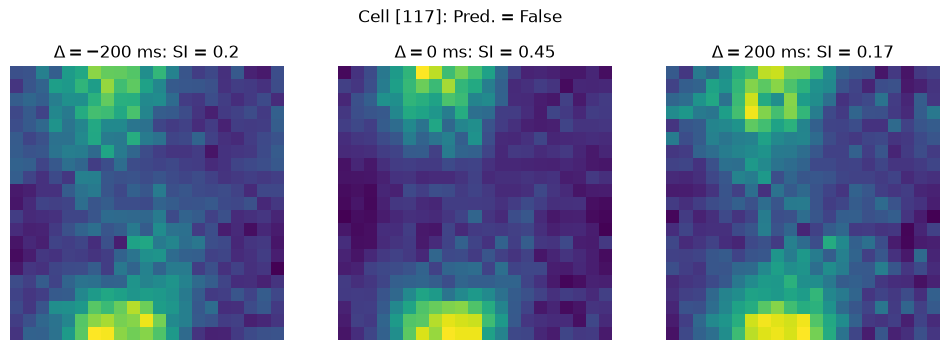

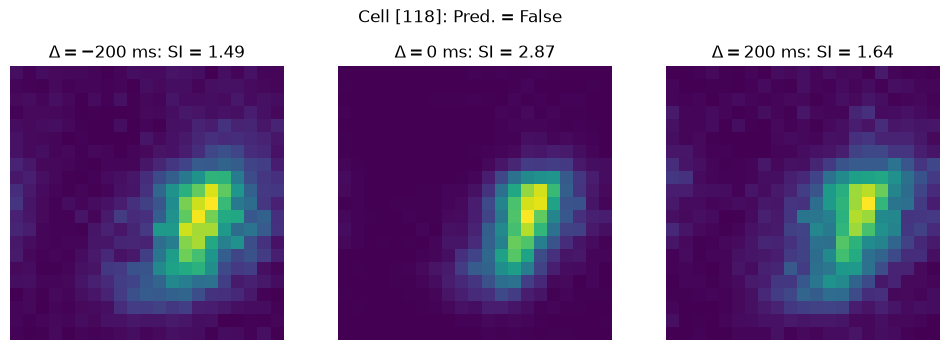

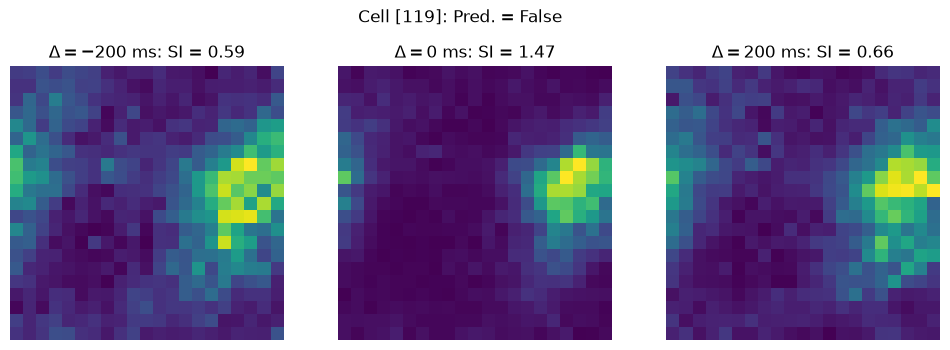

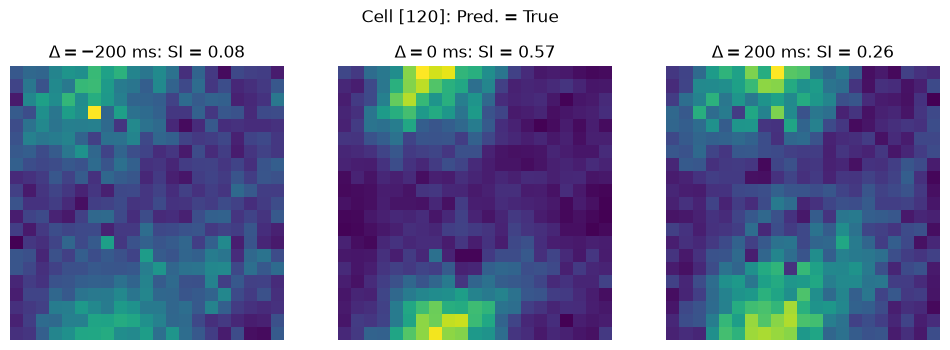

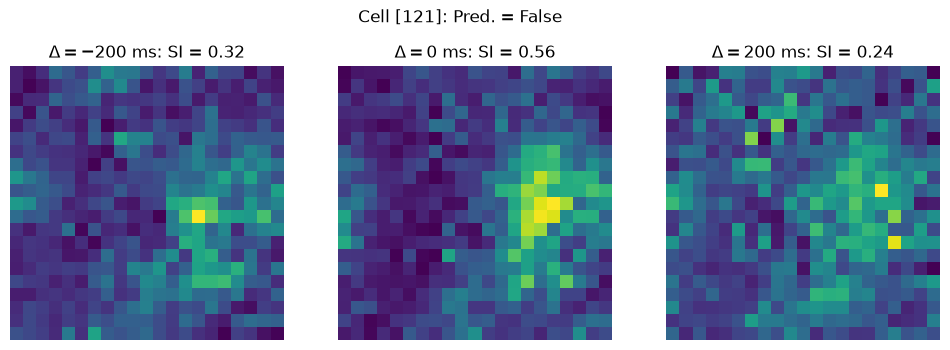

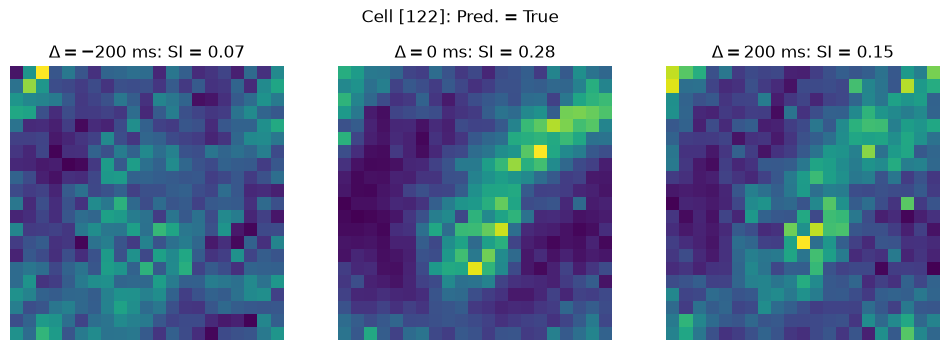

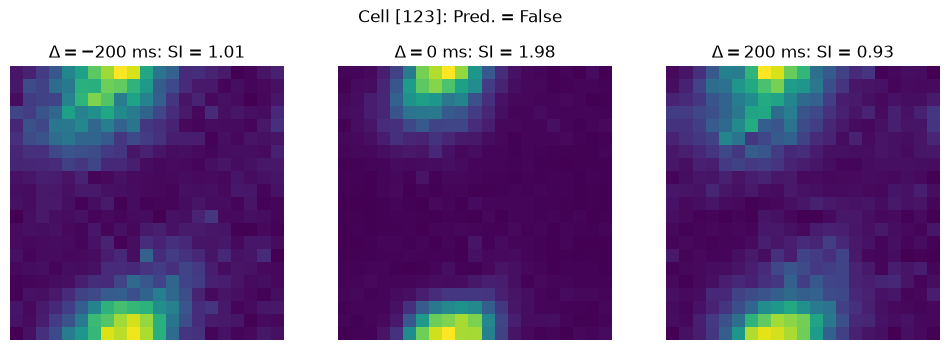

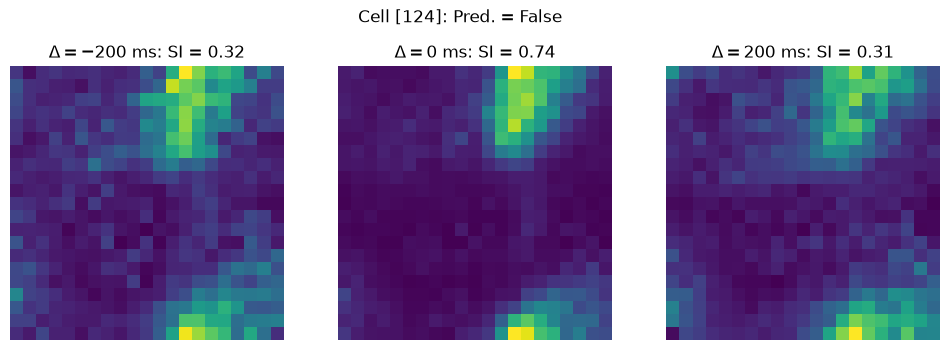

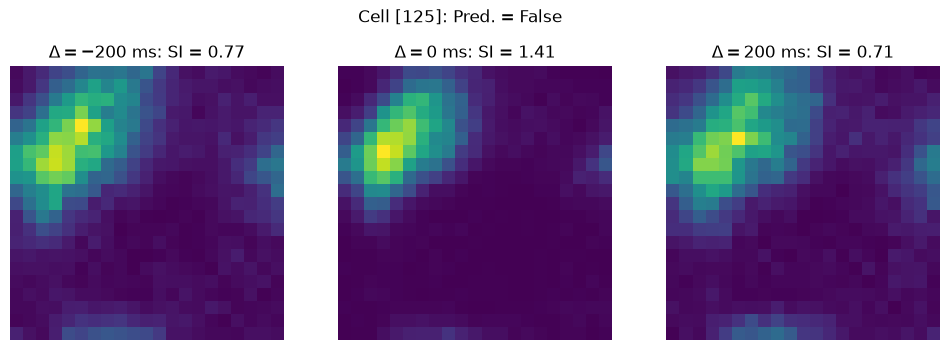

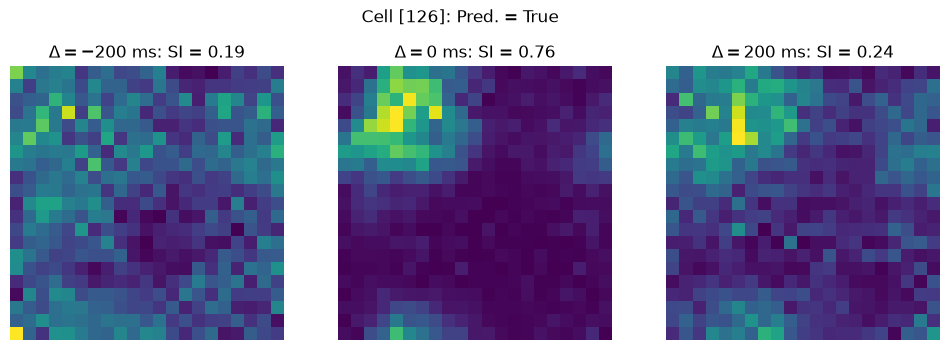

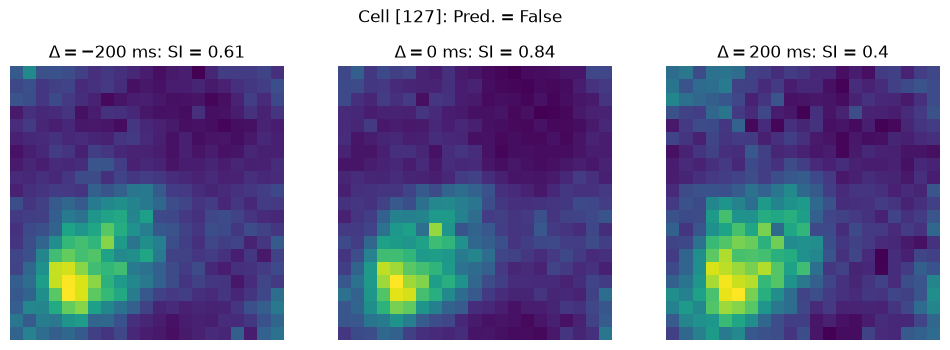

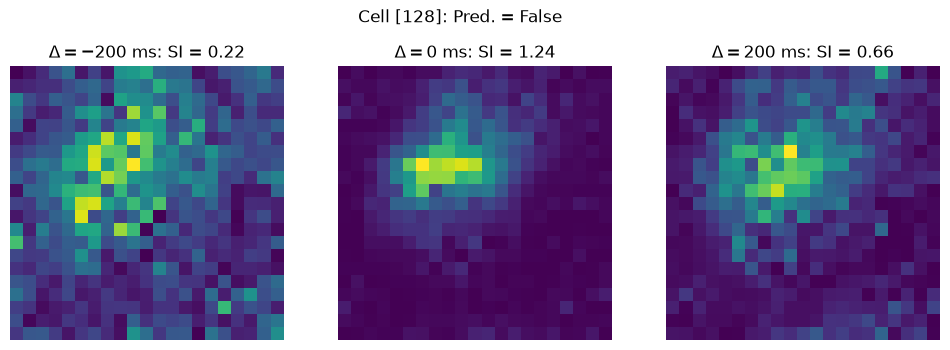

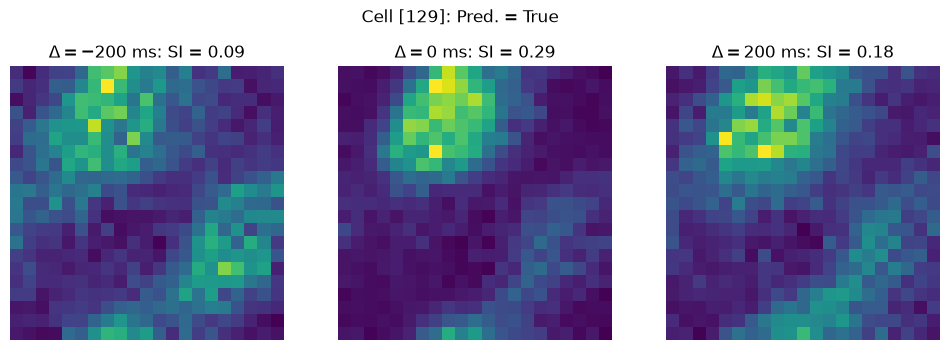

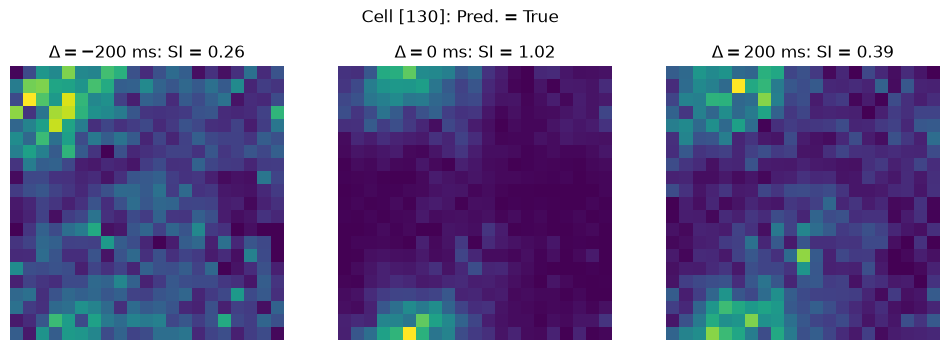

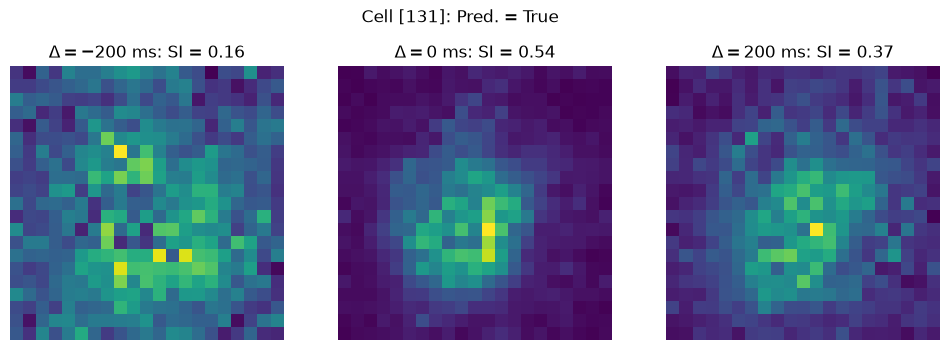

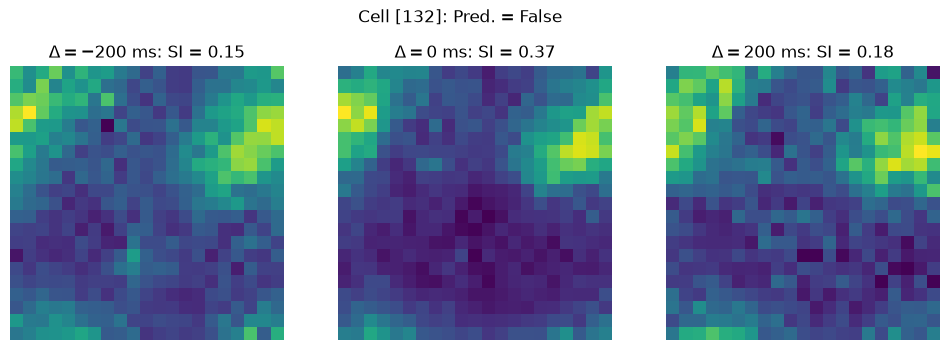

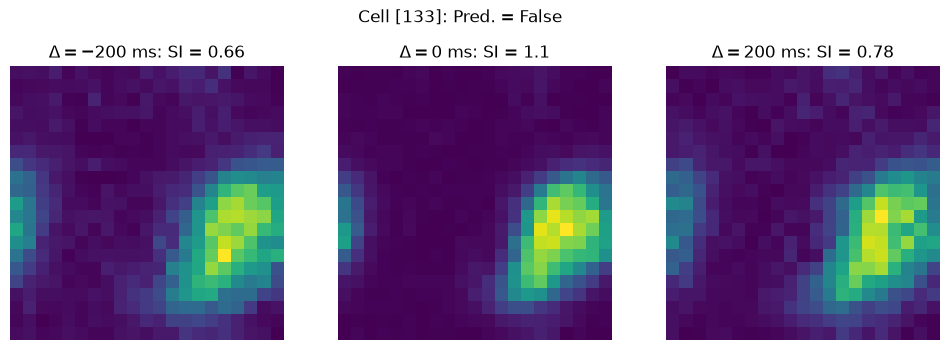

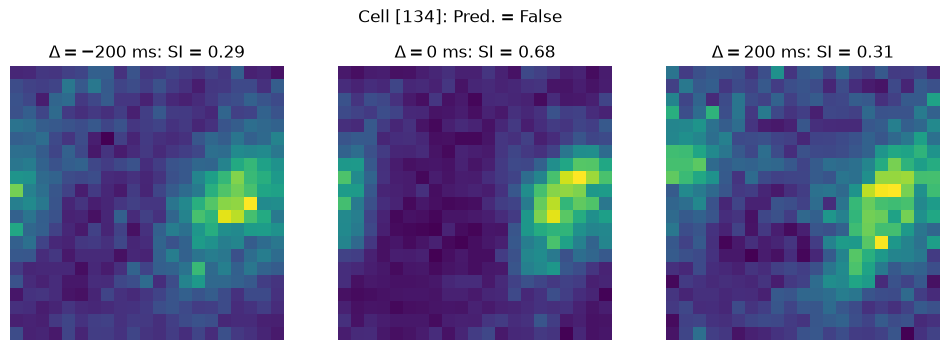

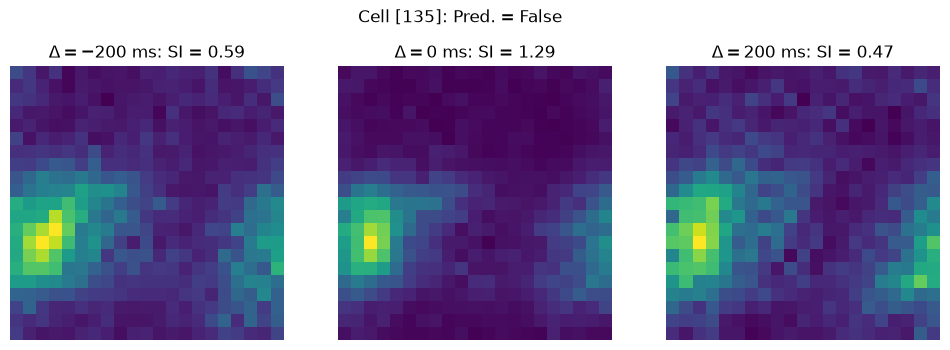

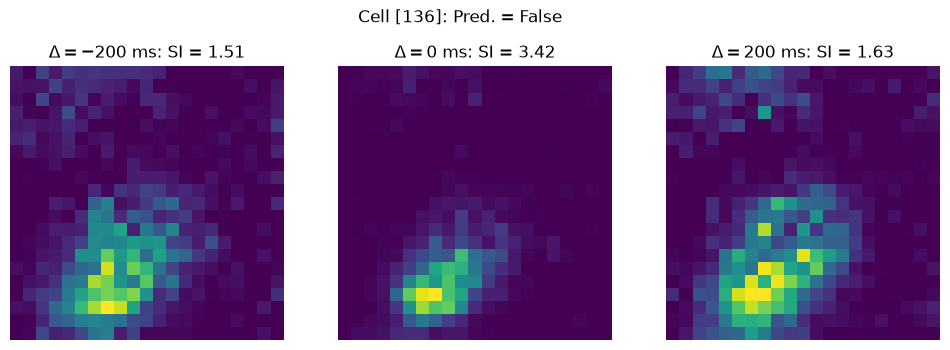

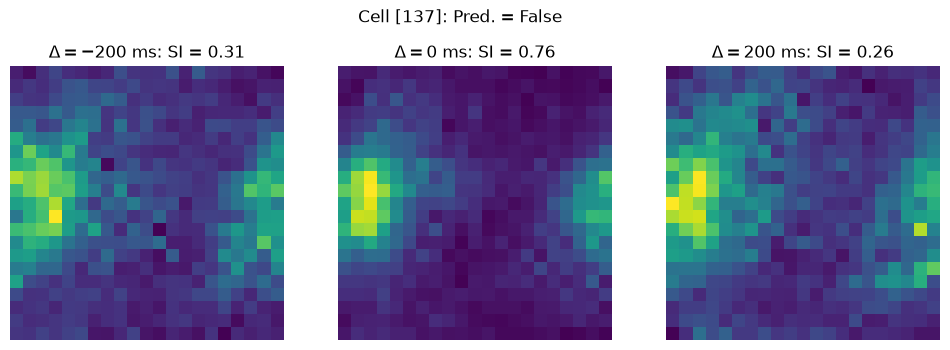

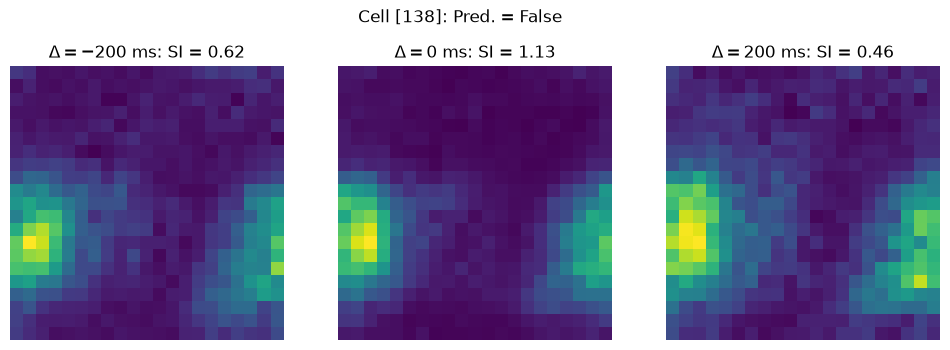

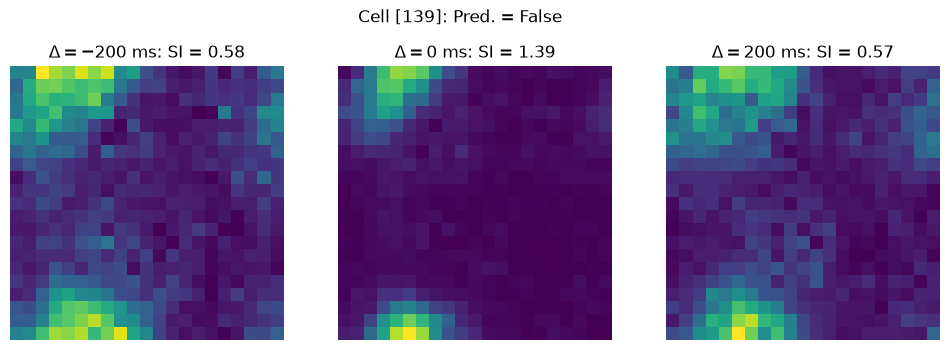

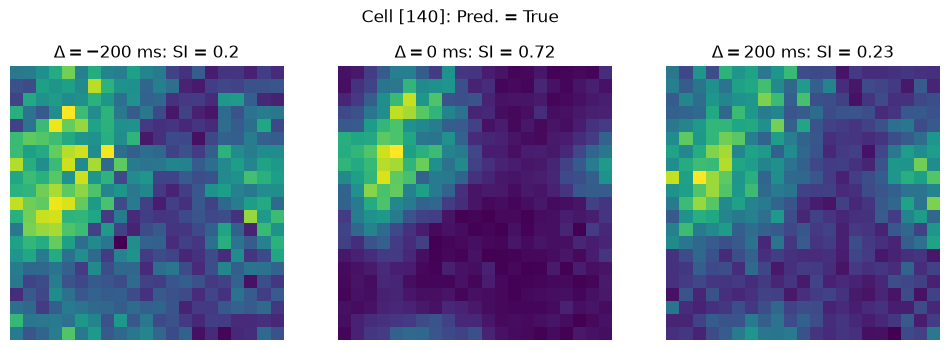

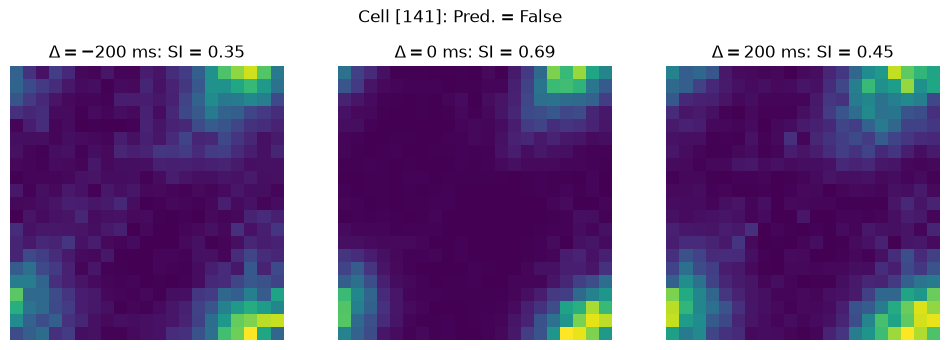

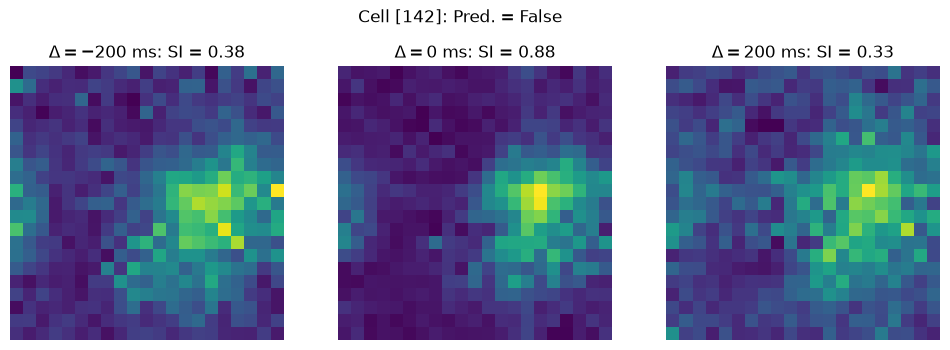

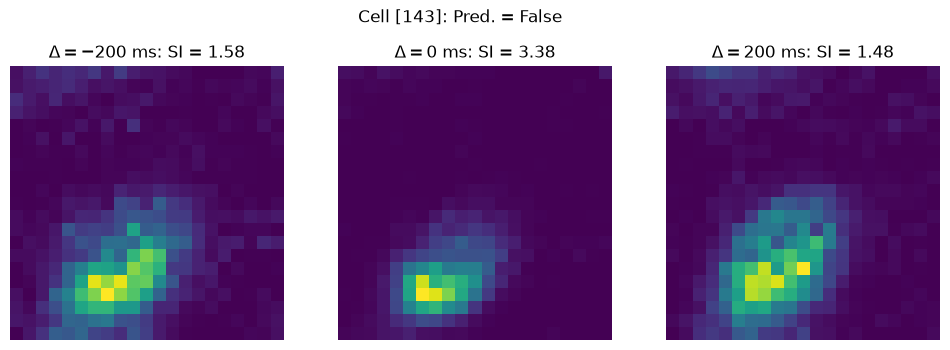

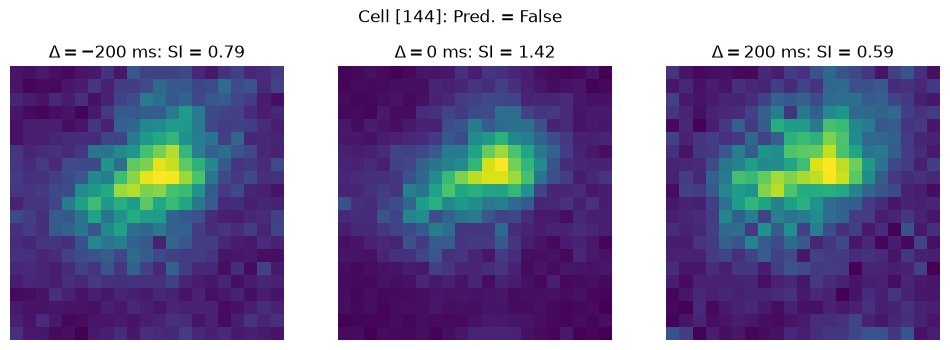

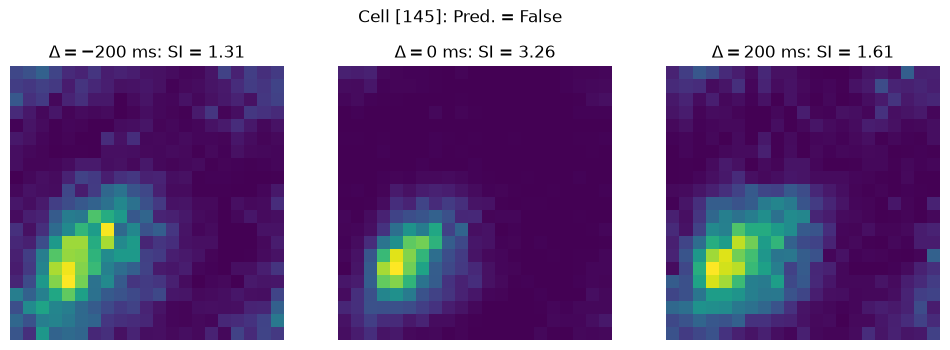

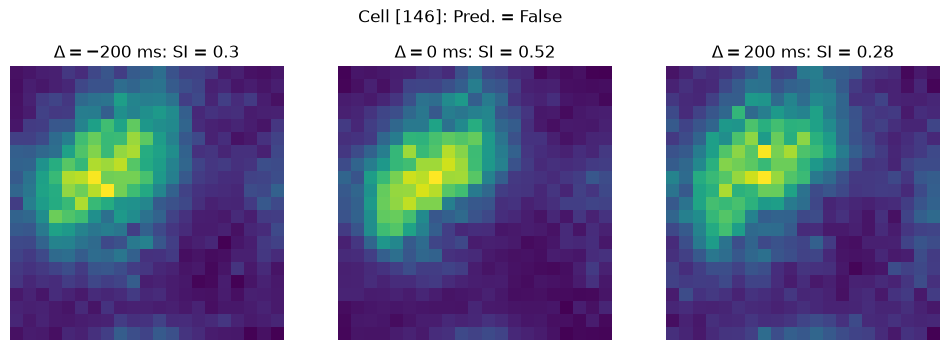

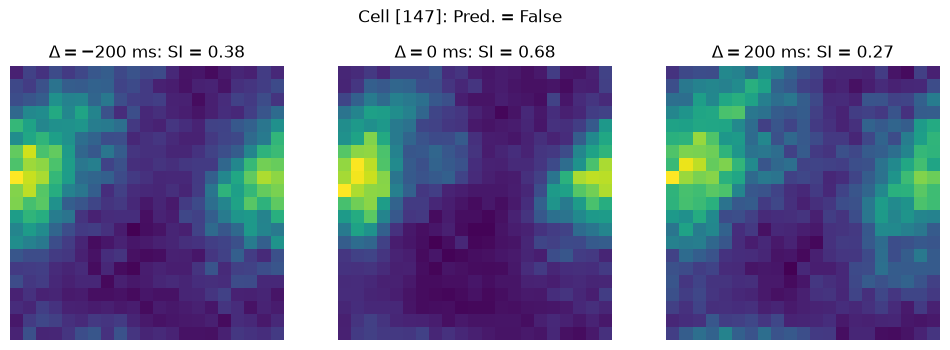

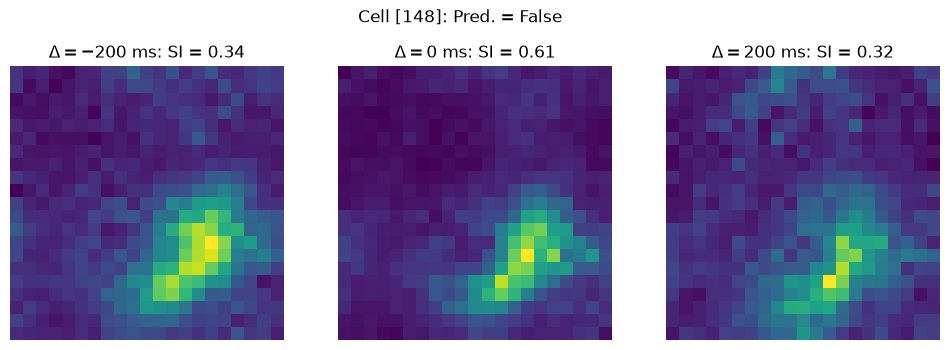

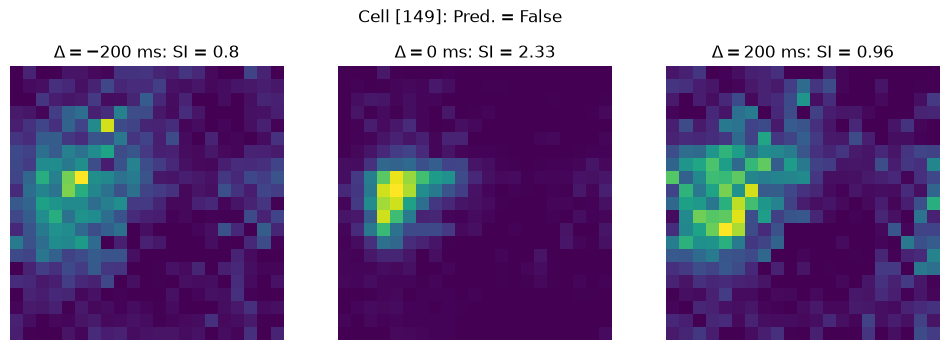

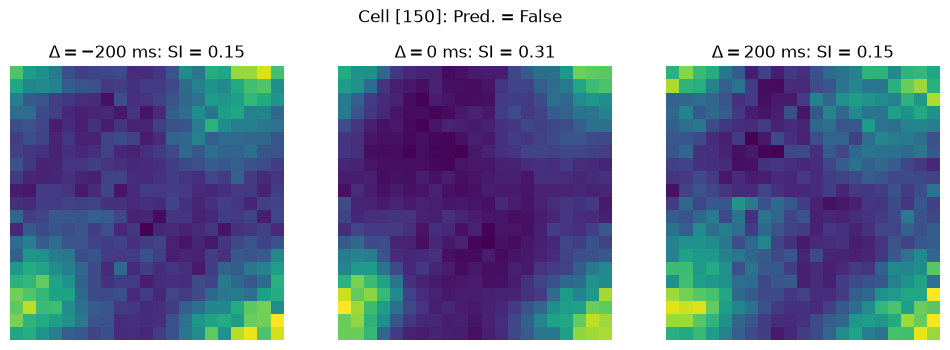

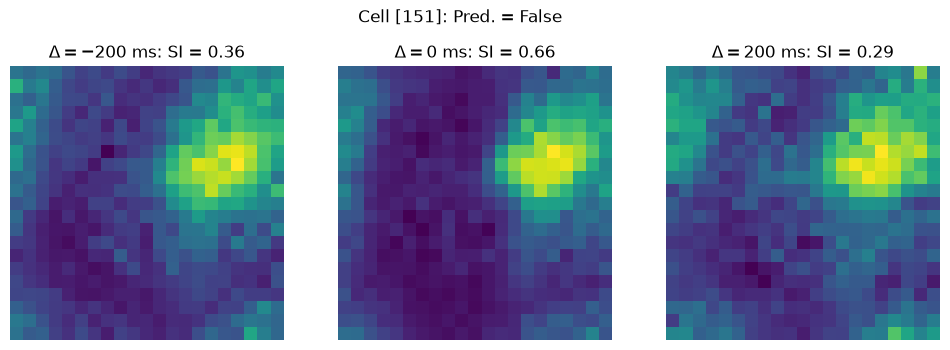

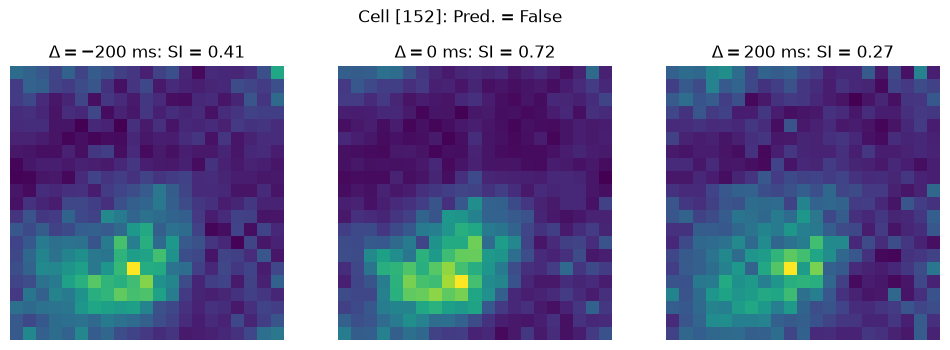

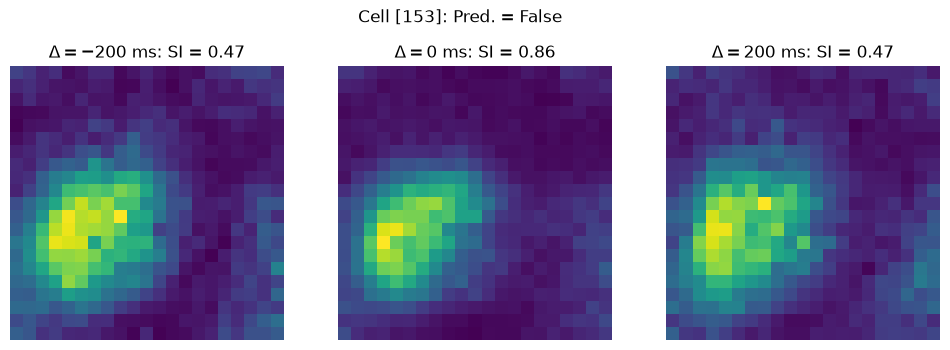

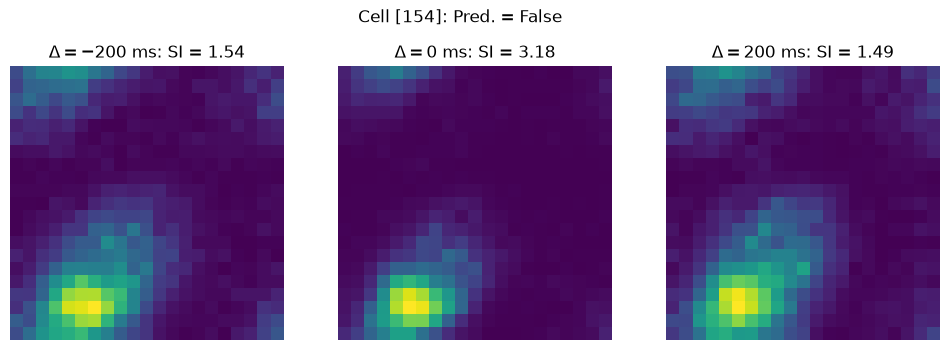

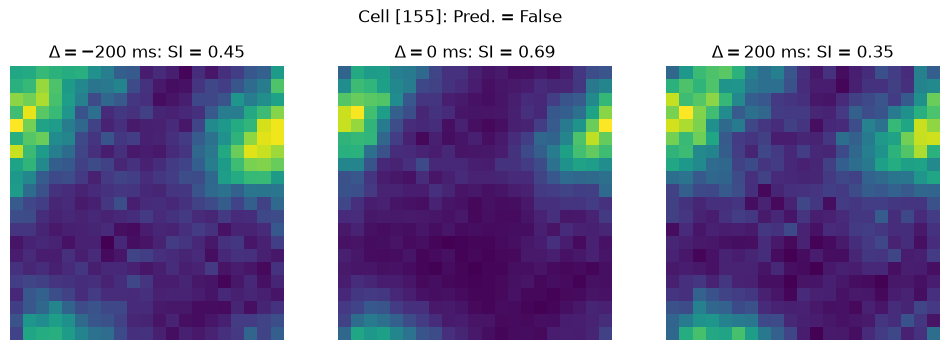

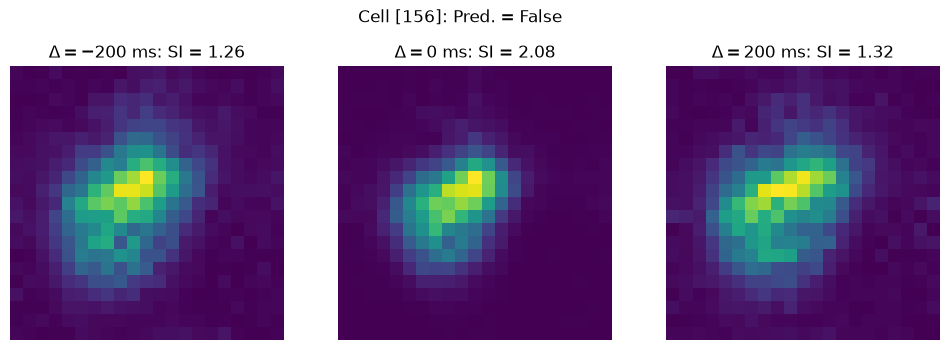

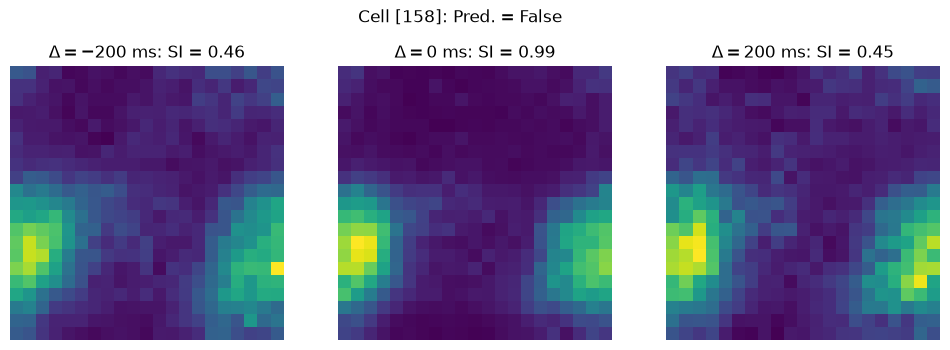

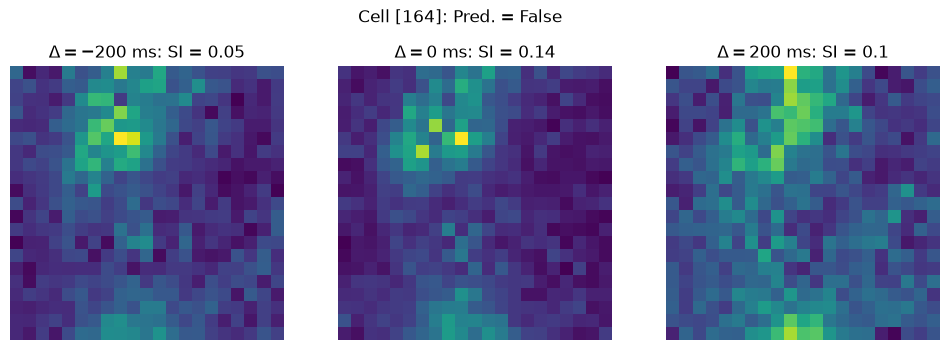

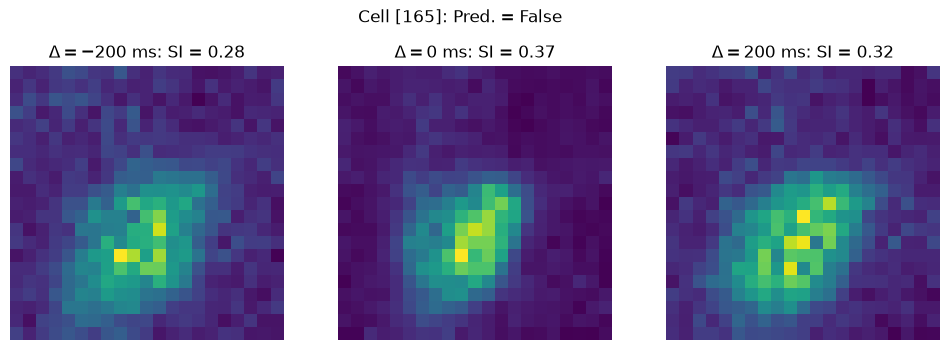

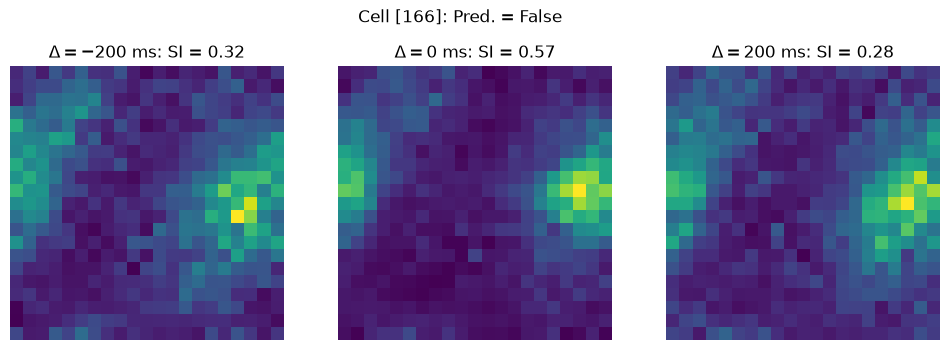

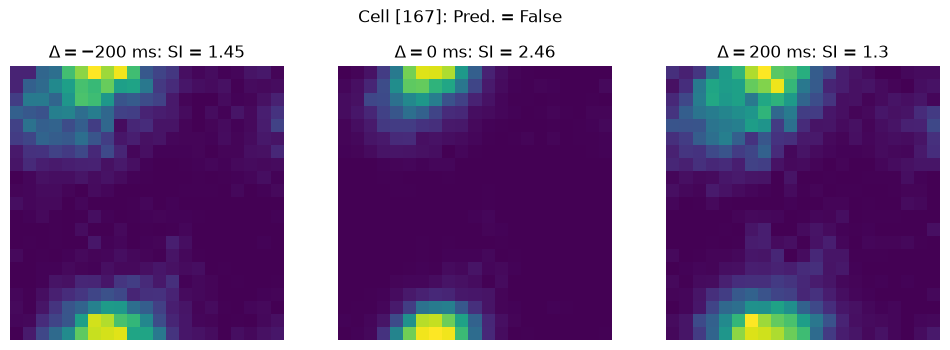

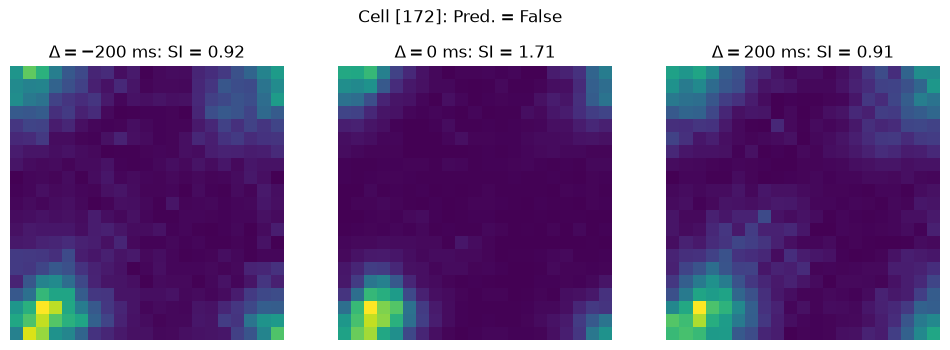

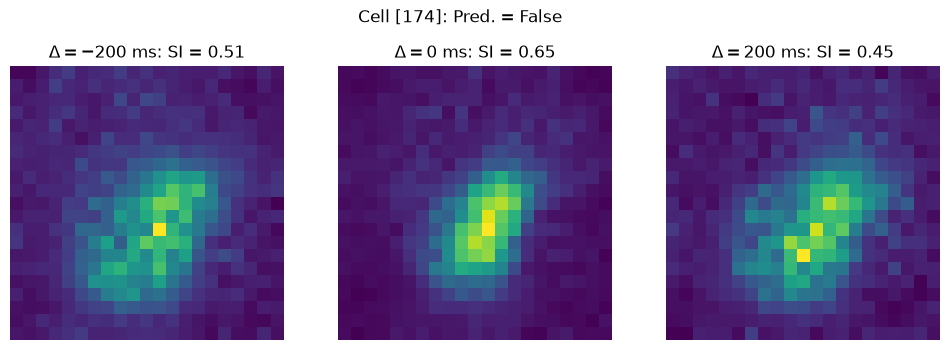

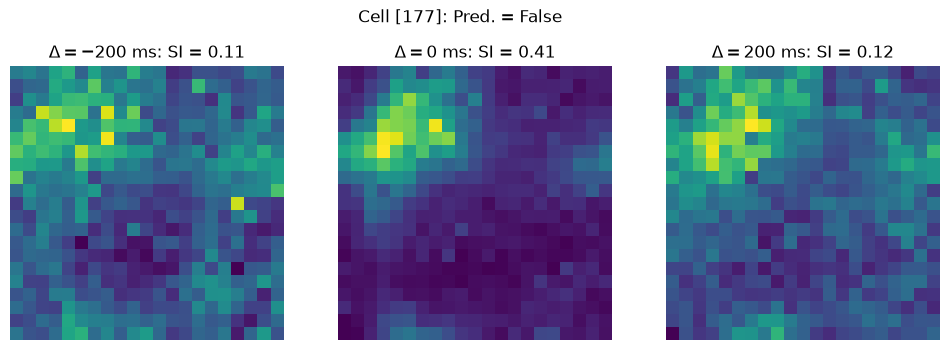

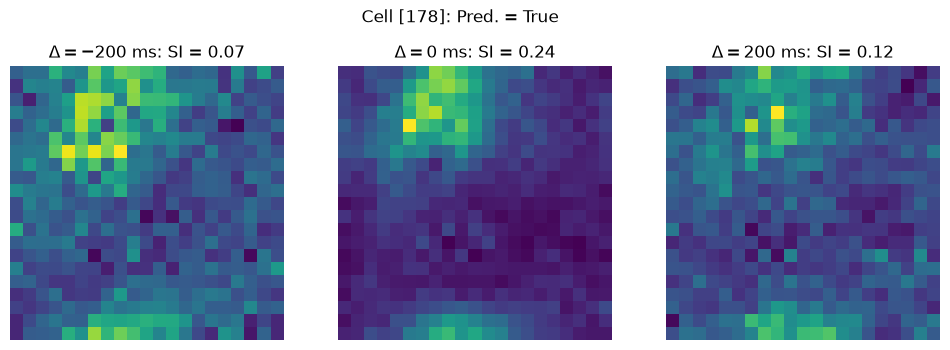

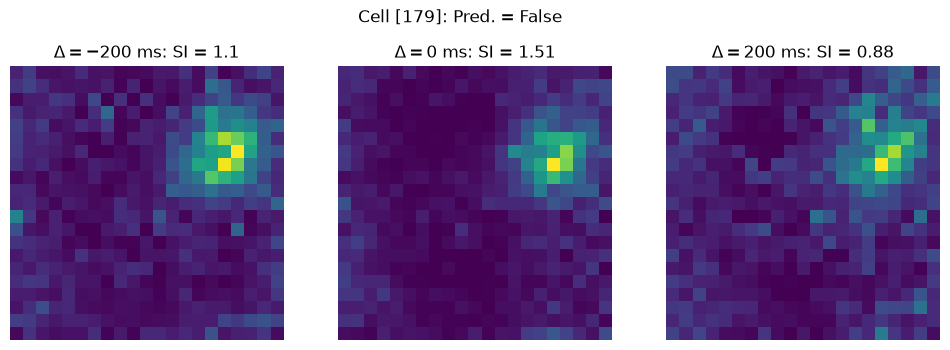

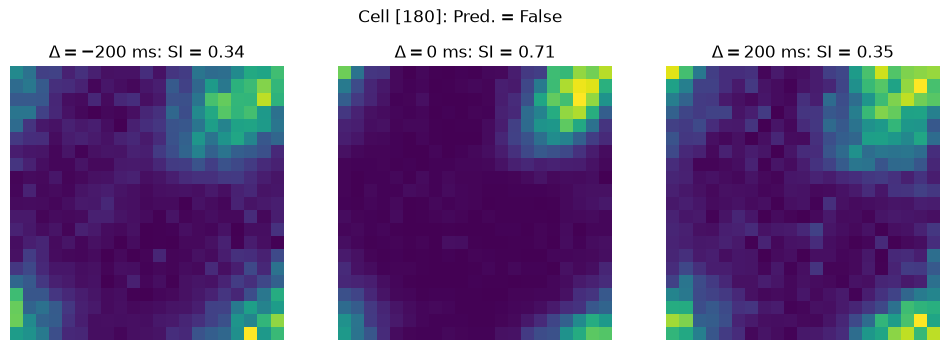

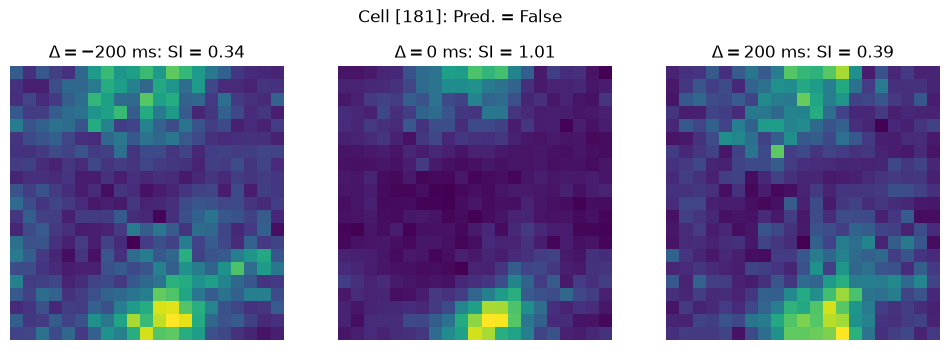

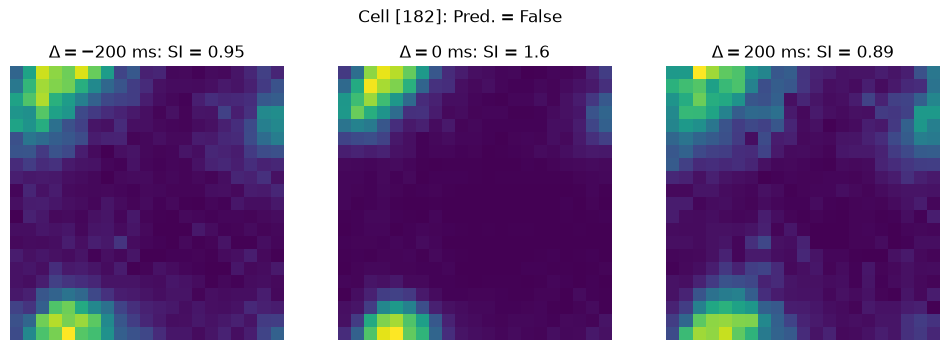

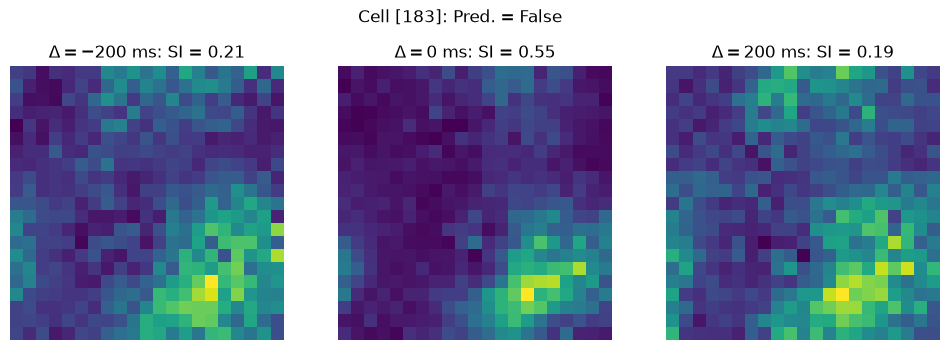

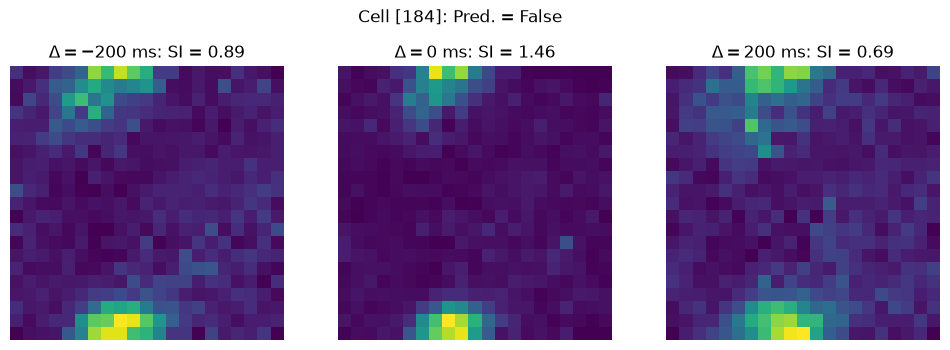

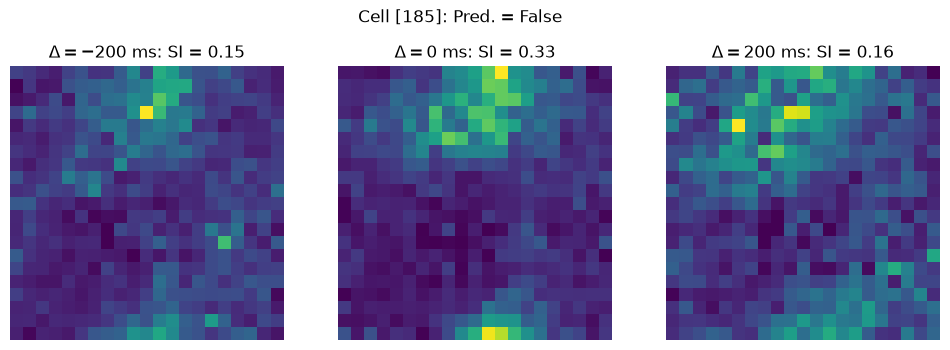

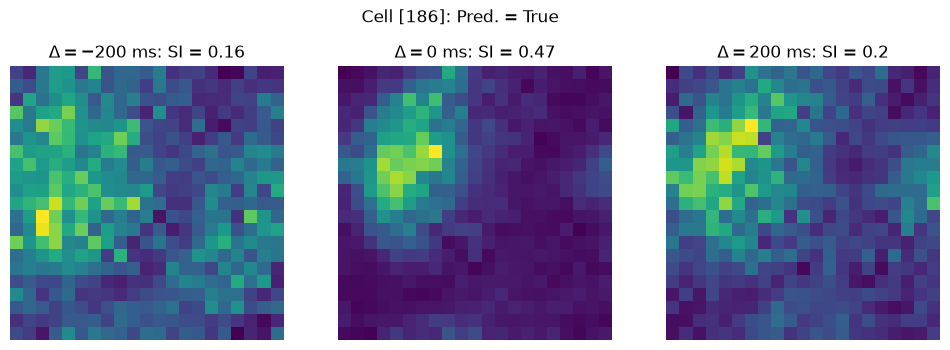

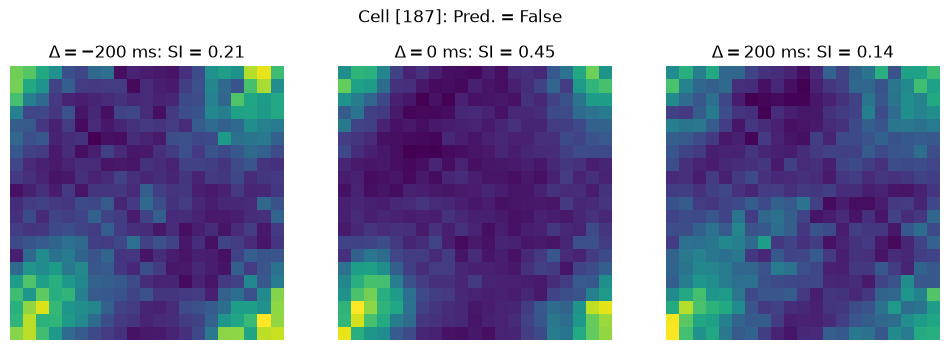

In [201]:
for ii in range(num_neurons):
    plt.figure(figsize = (12, 4))
    plt.subplot(1, 3, 2)
    plt.imshow(torus_ratemaps_shifted[ii, :, :, temporal_idx0[0][0]])
    plt.axis('off')
    plt.title('$\Delta = 0$ ms: SI = ' + str(np.round(spatial_info_shifted[ii, temporal_idx0[0][0]], 2)))
    plt.subplot(1, 3, 1)
    plt.imshow(torus_ratemaps_shifted[ii, :, :, np.argwhere(temporal_shifts == -10)[0][0]])
    plt.axis('off')
    plt.title('$\Delta = -200$ ms: SI = ' + str(np.round(spatial_info_shifted[ii, np.argwhere(temporal_shifts == -10)[0][0]], 2)))
    plt.subplot(1, 3, 3)
    plt.imshow(torus_ratemaps_shifted[ii, :, :, np.argwhere(temporal_shifts == 10)[0][0]])
    plt.axis('off')
    plt.title('$\Delta = 200$ ms: SI = ' + str(np.round(spatial_info_shifted[ii, np.argwhere(temporal_shifts == 10)[0][0]], 2)))

    plt.suptitle('Cell ' + str(non_conjunctive_cells[ii]) + ': Pred. = ' + str(len(np.intersect1d(ii, predictive_ids)) == 1))

    plt.savefig(results_save_path + 'Toroidal_ratemap_cell_' + str(non_conjunctive_cells[ii]) + '_' + exp + '.png')
    plt.savefig(results_save_path + 'Toroidal_ratemap_cell_' + str(non_conjunctive_cells[ii]) + '_' + exp + '.svg', format = 'svg')


[1.    0.01  0.255 0.805 0.947 0.805 0.614 0.255 0.255 0.614 0.418 0.947
 0.805 0.418 0.255 0.066 0.138 0.418 0.947 0.947]
[1.    0.187 0.83  0.888 0.475 0.284 0.232 0.068 0.116 0.284 0.406 0.475
 0.406 0.148 0.051 0.019 0.068 0.232 0.406 0.547]


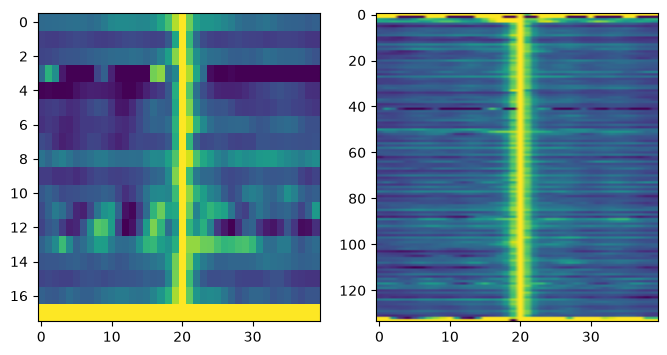

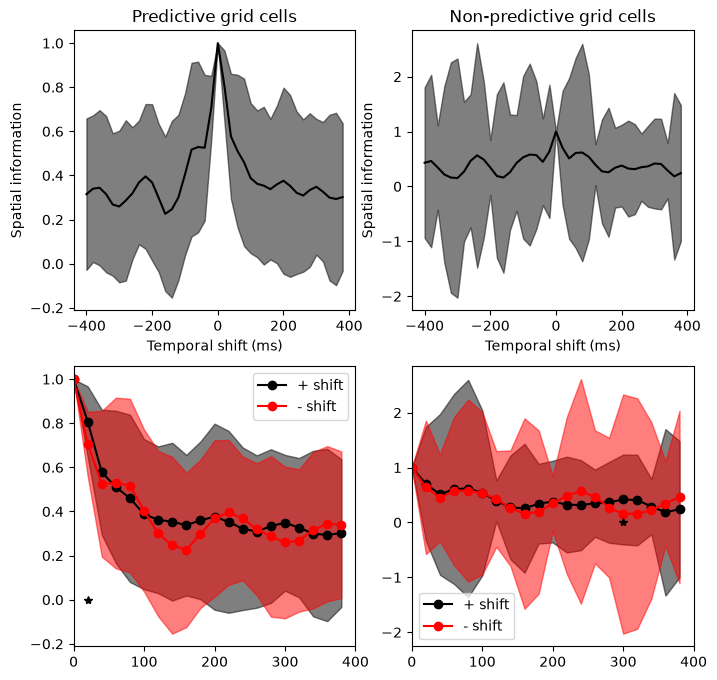

In [79]:
predictive_si_norm = spatial_info_shifted_norm[predictive_ids, :]
predictive_si_sorted_norm = predictive_si_norm[np.argsort(np.argmax(predictive_si_norm, axis = 1)), :]
non_predictive_si_norm = spatial_info_shifted_norm[non_predictive_ids, :]
non_predictive_si_sorted_norm = non_predictive_si_norm[np.argsort(np.argmax(non_predictive_si_norm, axis = 1)), :]

fig = plt.figure(figsize = (8, 4))
plt.subplot(1, 2, 1)
plt.imshow(predictive_si_sorted_norm, aspect ='auto')
plt.clim(0, 1)
plt.subplot(1, 2, 2)
plt.imshow(non_predictive_si_sorted_norm, aspect = 'auto')
plt.clim(0, 1)

 # Mean spatial info vs. shift
fig = plt.figure(figsize = (8, 8))
plt.subplot(2, 2, 1)
plt.fill_between(10 * temporal_shifts, np.mean(predictive_si_sorted_norm, axis = 0) - np.std(predictive_si_sorted_norm, axis = 0), np.mean(predictive_si_sorted_norm, axis = 0) + np.std(predictive_si_sorted_norm, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(predictive_si_sorted_norm, axis = 0), 'k-')
plt.xlabel('Temporal shift (ms)')
plt.ylabel('Spatial information')
plt.title('Predictive grid cells')

plt.subplot(2, 2, 2)
plt.fill_between(10 * temporal_shifts, np.mean(non_predictive_si_sorted_norm, axis = 0) - np.std(non_predictive_si_sorted_norm, axis = 0), np.mean(non_predictive_si_sorted_norm, axis = 0) + np.std(non_predictive_si_sorted_norm, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(non_predictive_si_sorted_norm, axis = 0), 'k-')
plt.xlabel('Temporal shift (ms)')
plt.ylabel('Spatial information')
plt.title('Non-predictive grid cells')

p_values_predictive = np.zeros(int(np.floor(n_shifts / 2)))
for s in range(int(np.floor(n_shifts / 2))):
    p_values_predictive[s] = scipy.stats.kstest(predictive_si_sorted_norm[:, int(temporal_idx0[0][0]) + s], predictive_si_sorted_norm[:, int(temporal_idx0[0][0]) - s], alternative = 'less').pvalue
print(np.round(p_values_predictive, 3))

plt.subplot(2, 2, 3)
plt.fill_between(10 * temporal_shifts, np.mean(predictive_si_sorted_norm, axis = 0) - np.std(predictive_si_sorted_norm, axis = 0), np.mean(predictive_si_sorted_norm, axis = 0) + np.std(predictive_si_sorted_norm, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(predictive_si_sorted_norm, axis = 0), 'ko-', label = '+ shift')
plt.fill_between(10 * temporal_shifts[1:], np.flip((np.mean(predictive_si_sorted_norm, axis = 0) - np.std(predictive_si_sorted_norm, axis = 0)))[:-1], np.flip((np.mean(predictive_si_sorted_norm, axis = 0) + np.std(predictive_si_sorted_norm, axis = 0)))[:-1], alpha = 0.5, color = 'r')
plt.plot(10 * temporal_shifts[1:], np.flip(np.mean(predictive_si_sorted_norm, axis = 0))[:-1], 'ro-', label = '- shift')
for s in range(int(np.floor(n_shifts / 2))):
    if p_values_predictive[s] < 0.05:
        plt.plot(10 * temporal_shifts[temporal_idx0 + s], 0.0, 'k*')
plt.xlim(0, 400)
plt.legend()

p_values_non_predictive = np.zeros(int(np.floor(n_shifts / 2)))
for s in range(int(np.floor(n_shifts / 2))):
    p_values_non_predictive[s] = scipy.stats.kstest(non_predictive_si_sorted_norm[:, int(temporal_idx0[0][0]) + s], non_predictive_si_sorted_norm[:, int(temporal_idx0[0][0]) - s], alternative = 'less').pvalue
print(np.round(p_values_non_predictive, 3))

plt.subplot(2, 2, 4)
plt.fill_between(10 * temporal_shifts, np.mean(non_predictive_si_sorted_norm, axis = 0) - np.std(non_predictive_si_sorted_norm, axis = 0), np.mean(non_predictive_si_sorted_norm, axis = 0) + np.std(non_predictive_si_sorted_norm, axis = 0), alpha = 0.5, color = 'k')
plt.plot(10 * temporal_shifts, np.mean(non_predictive_si_sorted_norm, axis = 0), 'ko-', label = '+ shift')
plt.fill_between(10 * temporal_shifts[1:], np.flip((np.mean(non_predictive_si_sorted_norm, axis = 0) - np.std(non_predictive_si_sorted_norm, axis = 0)))[:-1], np.flip((np.mean(non_predictive_si_sorted_norm, axis = 0) + np.std(non_predictive_si_sorted_norm, axis = 0)))[:-1], alpha = 0.5, color = 'r')
plt.plot(10 * temporal_shifts[1:], np.flip(np.mean(non_predictive_si_sorted_norm, axis = 0))[:-1], 'ro-', label = '- shift')
for s in range(int(np.floor(n_shifts / 2))):
    if p_values_non_predictive[s] < 0.05:
        plt.plot(10 * temporal_shifts[temporal_idx0 + s], 0.0, 'k*')
plt.xlim(0, 400)
plt.legend()

In [316]:
import copy

# Decoding
n_splits = 5
n_shifts = len(temporal_shifts)

decoding_error = np.zeros((n_shifts, n_splits))
decoding_error_no_predictive = np.zeros((n_shifts, n_splits))
decoding_error_no_grid = np.zeros((n_shifts, n_splits))
decoding_error_no_non_grid = np.zeros((n_shifts, n_splits))
n_remove = len(np.intersect1d(temporal_predictive_grid_cells, non_conjunctive_cells))
grid_scores = temporal_grid_scores[temporal_idx0, non_conjunctive_cells].flatten()
grid_ids_sorted = np.argsort(grid_scores)

for i in range(n_splits):
    print(i)
    for s in range(len(temporal_shifts)):
        # Generating shifted data
        if temporal_shifts[s] < 0:
            torus_0_binned_shifted = torus_0_binned[:temporal_shifts[s]]
            torus_1_binned_shifted = torus_1_binned[:temporal_shifts[s]]
            sspikes_shifted = sspikes[-temporal_shifts[s]:, :]
        elif temporal_shifts[s] == 0:
            torus_0_binned_shifted = torus_0_binned
            torus_1_binned_shifted = torus_1_binned
            sspikes_shifted = sspikes
        else:
            torus_0_binned_shifted = torus_0_binned[temporal_shifts[s]:]
            torus_1_binned_shifted = torus_1_binned[temporal_shifts[s]:]
            sspikes_shifted = sspikes[:-temporal_shifts[s], :]

        # Splitting data into train and test
        T = len(torus_0_binned_shifted)
        train_time = np.concatenate((np.arange(0, np.round((i * T) / n_splits), 1), np.arange(np.round(((i + 1) * T) / n_splits), T, 1))).astype('int')
        test_time = np.arange(np.round((i * T) / n_splits), np.round(((i + 1) * T) / n_splits), 1).astype('int')

        train_torus_0 = torus_0_binned_shifted[train_time]
        train_torus_1 = torus_1_binned_shifted[train_time]
        train_sspikes = sspikes_shifted[train_time]

        test_torus_0 = torus_0_binned_shifted[test_time]
        test_torus_1 = torus_1_binned_shifted[test_time]
        test_sspikes = sspikes_shifted[test_time]

        # Constructing train ratemaps
        train_ratemaps = np.zeros((num_neurons, n_torus_bins + 1, n_torus_bins + 1))
        train_occupancy = np.zeros((n_torus_bins + 1, n_torus_bins + 1))
        for t in range(len(train_torus_0)):
            train_ratemaps[:, int(train_torus_0[t]), int(train_torus_1[t])] += train_sspikes[t, :]
            torus_occupancy[int(train_torus_0[t]), int(train_torus_1[t])] += 1

        train_ratemaps = train_ratemaps / torus_occupancy
        train_ratemaps_no_predictive = copy.deepcopy(train_ratemaps)
        train_ratemaps_no_grid = copy.deepcopy(train_ratemaps)
        train_ratemaps_no_non_grid = copy.deepcopy(train_ratemaps)

        # Decoding test activity
        decoded_torus_0 = np.zeros(len(test_torus_0))
        decoded_torus_1 = np.zeros(len(test_torus_1))

        for t in range(len(test_torus_0)):
            summed_ratemap = test_sspikes[t, :] @ train_ratemaps.reshape((np.shape(train_ratemaps)[0], np.shape(train_ratemaps)[1] * np.shape(train_ratemaps)[2]))
            decoded_torus_0[t], decoded_torus_1[t] = np.unravel_index(np.argmax(summed_ratemap), (n_torus_bins + 1, n_torus_bins + 1))

        decoding_error_0 = np.min(np.vstack((np.abs(decoded_torus_0 - test_torus_0), np.abs(decoded_torus_0 - test_torus_0 + n_torus_bins))), axis = 0)
        decoding_error_1 = np.min(np.vstack((np.abs(decoded_torus_1 - test_torus_1), np.abs(decoded_torus_1 - test_torus_1 + n_torus_bins))), axis = 0)
        decoding_error[s, i] = np.median(np.sqrt((decoding_error_0**2 + decoding_error_1**2)))

        # Removing predictive grid cells
        for ii in range(num_neurons):
            if len(np.intersect1d(ii, temporal_predictive_grid_cells)) > 0  and len(np.intersect1d(ii, non_conjunctive_cells)) > 0:
                train_ratemaps_no_predictive[ii, :, :] = 0

        # Decoding test activity: no predictive grid cells
        decoded_torus_0_no_predictive = np.zeros(len(test_torus_0))
        decoded_torus_1_no_predictive = np.zeros(len(test_torus_1))

        for t in range(len(test_torus_0)):
            summed_ratemap_no_predictive = test_sspikes[t, :] @ train_ratemaps_no_predictive.reshape((np.shape(train_ratemaps_no_predictive)[0], np.shape(train_ratemaps_no_predictive)[1] * np.shape(train_ratemaps_no_predictive)[2]))
            decoded_torus_0_no_predictive[t], decoded_torus_1_no_predictive[t] = np.unravel_index(np.argmax(summed_ratemap_no_predictive), (n_torus_bins + 1, n_torus_bins + 1))

        decoding_error_0_no_predictive = np.min(np.vstack((np.abs(decoded_torus_0_no_predictive - test_torus_0), np.abs(decoded_torus_0_no_predictive - test_torus_0 + n_torus_bins))), axis = 0)
        decoding_error_1_no_predictive = np.min(np.vstack((np.abs(decoded_torus_1_no_predictive - test_torus_1), np.abs(decoded_torus_1_no_predictive - test_torus_1 + n_torus_bins))), axis = 0)
        decoding_error_no_predictive[s, i] = np.median(np.sqrt((decoding_error_0_no_predictive**2 + decoding_error_1_no_predictive**2)))

        # Removing grid cells
        train_ratemaps_no_grid[grid_ids_sorted[(-n_remove):], :, :] = 0

        # Decoding test activity: no grid cells
        decoded_torus_0_no_grid = np.zeros(len(test_torus_0))
        decoded_torus_1_no_grid = np.zeros(len(test_torus_1))

        for t in range(len(test_torus_0)):
            summed_ratemap_no_grid = test_sspikes[t, :] @ train_ratemaps_no_grid.reshape((np.shape(train_ratemaps_no_grid)[0], np.shape(train_ratemaps_no_grid)[1] * np.shape(train_ratemaps_no_grid)[2]))
            decoded_torus_0_no_grid[t], decoded_torus_1_no_grid[t] = np.unravel_index(np.argmax(summed_ratemap_no_grid), (n_torus_bins + 1, n_torus_bins + 1))

        decoding_error_0_no_grid = np.min(np.vstack((np.abs(decoded_torus_0_no_grid - test_torus_0), np.abs(decoded_torus_0_no_grid - test_torus_0 + n_torus_bins))), axis = 0)
        decoding_error_1_no_grid = np.min(np.vstack((np.abs(decoded_torus_1_no_grid - test_torus_1), np.abs(decoded_torus_1_no_grid - test_torus_1 + n_torus_bins))), axis = 0)
        decoding_error_no_grid[s, i] = np.median(np.sqrt((decoding_error_0_no_grid**2 + decoding_error_1_no_grid**2)))

        # Removing non grid cells
        train_ratemaps_no_non_grid[grid_ids_sorted[:n_remove], :, :] = 0

        # Decoding test activity: no non grid cells
        decoded_torus_0_no_non_grid = np.zeros(len(test_torus_0))
        decoded_torus_1_no_non_grid = np.zeros(len(test_torus_1))

        for t in range(len(test_torus_0)):
            summed_ratemap_no_non_grid = test_sspikes[t, :] @ train_ratemaps_no_non_grid.reshape((np.shape(train_ratemaps_no_non_grid)[0], np.shape(train_ratemaps_no_non_grid)[1] * np.shape(train_ratemaps_no_non_grid)[2]))
            decoded_torus_0_no_non_grid[t], decoded_torus_1_no_non_grid[t] = np.unravel_index(np.argmax(summed_ratemap_no_non_grid), (n_torus_bins + 1, n_torus_bins + 1))

        decoding_error_0_no_non_grid = np.min(np.vstack((np.abs(decoded_torus_0_no_non_grid - test_torus_0), np.abs(decoded_torus_0_no_non_grid - test_torus_0 + n_torus_bins))), axis = 0)
        decoding_error_1_no_non_grid = np.min(np.vstack((np.abs(decoded_torus_1_no_non_grid - test_torus_1), np.abs(decoded_torus_1_no_non_grid - test_torus_1 + n_torus_bins))), axis = 0)
        decoding_error_no_non_grid[s, i] = np.median(np.sqrt((decoding_error_0_no_non_grid**2 + decoding_error_1_no_non_grid**2)))


0
1
2
3
4


FileNotFoundError: [Errno 2] No such file or directory: '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r23/Torus/Decoding_error.png'

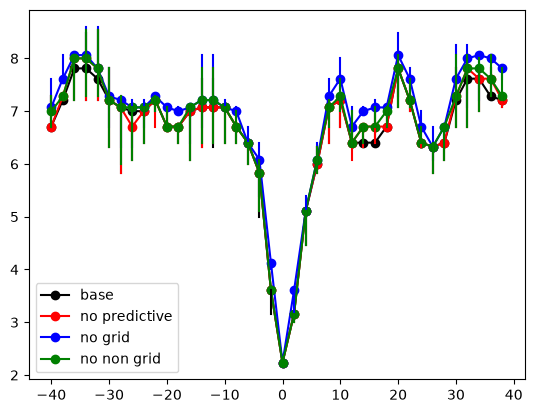

In [318]:
plt.plot(temporal_shifts, np.nanmedian(decoding_error, axis = 1), 'ko-', label='base')
plt.plot(temporal_shifts, np.nanmedian(decoding_error_no_predictive, axis = 1), 'ro-', label='no predictive')
plt.plot(temporal_shifts, np.nanmedian(decoding_error_no_grid, axis = 1), 'bo-', label='no grid')
plt.plot(temporal_shifts, np.nanmedian(decoding_error_no_non_grid, axis = 1), 'go-', label='no non grid')
for s in range(n_shifts):
    plt.plot([temporal_shifts[s], temporal_shifts[s]], [np.percentile(decoding_error[s, :], 25), np.percentile(decoding_error[s, :], 75)], 'k-')
    plt.plot([temporal_shifts[s], temporal_shifts[s]], [np.percentile(decoding_error_no_predictive[s, :], 25), np.percentile(decoding_error_no_predictive[s, :], 75)], 'r-')
    plt.plot([temporal_shifts[s], temporal_shifts[s]], [np.percentile(decoding_error_no_grid[s, :], 25), np.percentile(decoding_error_no_grid[s, :], 75)], 'b-')
    plt.plot([temporal_shifts[s], temporal_shifts[s]], [np.percentile(decoding_error_no_non_grid[s, :], 25), np.percentile(decoding_error_no_non_grid[s, :], 75)], 'g-')
plt.legend()
plt.savefig(results_save_path + 'Decoding_error.png')
plt.savefig(results_save_path + 'Decoding_error.svg', format = 'svg')